<a href="https://www.kaggle.com/code/nmavros/deepfire-forecaster?scriptVersionId=300798105" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# 🔥 DeepFire Forecaster
### Hybrid CNN-Transformer for Wildfire Spread Prediction
**Dataset:** TS-SAT Fire (Kaggle)  
**Task:** Given 3 days of VIIRS thermal + LULC data → predict Day-4 fire probability heatmap  
**Architecture:** Spatial CNN Encoder → Spatiotemporal Transformer → Temporal Attention Pooling → UNet-style Decoder  
**Loss:** Masked Focal-Dice Loss (handles severe class imbalance)

---


In [1]:
# Install dependencies (Kaggle environment already has most of these)
import subprocess, sys

required = ["rasterio", "tqdm"]
for pkg in required:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

print("✅ All dependencies ready.")


✅ All dependencies ready.


## 1. Imports & Reproducibility

In [2]:
import os
import glob
import json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import rasterio
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from torch.utils.data import Dataset, DataLoader, random_split
from tqdm.auto import tqdm
from IPython.display import FileLink, display

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42

def set_seed(seed: int = SEED):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🔧 Device: {DEVICE}")
print(f"🔧 PyTorch: {torch.__version__}")


🔧 Device: cuda
🔧 PyTorch: 2.9.0+cu126


## 2. Global Configuration

In [3]:
# ─── Paths ───────────────────────────────────────────────────────────────────
DATA_ROOT   = "/kaggle/input/ts-satfire/ts-satfire"
SAVE_DIR    = "/kaggle/working"
MODEL_PATH  = os.path.join(SAVE_DIR, "deepfire_best.pt")

# ─── Data ────────────────────────────────────────────────────────────────────
SPATIAL_SIZE    = 128          # Reduced from 256 to cut RAM 4×          # Resize all imagery to this (pixels × pixels)
SEQ_LEN         = 3           # Number of input days  (Days 1-3)
VIIRS_CHANNELS  = 8           # Bands per VIIRS_Day .tif (always 8)
LULC_CLASSES    = 12          # ESRI LULC discrete classes (0-11)
NIGHT_CHANNELS  = 2           # Bands per VIIRS_Night .tif (always 2)
LULC_EMBED_DIM  = 8           # Learnable embedding size per LULC class
USE_NIGHT       = True        # Also fuse VIIRS_Night observations
VIIRS_CLIP_MIN  = 200.0       # Brightness temperature physical range (K)
VIIRS_CLIP_MAX  = 400.0

# ─── Architecture ────────────────────────────────────────────────────────────
EMBED_DIM       = 128         # CNN + Transformer feature dimension
NUM_HEADS       = 4           # Transformer attention heads
NUM_LAYERS      = 3           # Transformer encoder layers
DROPOUT         = 0.1

# ─── Training ────────────────────────────────────────────────────────────────
BATCH_SIZE      = 2            # Reduced to ease GPU + CPU RAM pressure
EPOCHS          = 20
LR              = 1e-4
WEIGHT_DECAY    = 1e-4
GRAD_CLIP       = 1.0         # Max gradient norm
SPLIT_TRAIN     = 0.70
SPLIT_VAL       = 0.15        # Remainder → test

# ─── Loss ────────────────────────────────────────────────────────────────────
FOCAL_GAMMA     = 2.0         # Focal loss focusing parameter
FOCAL_ALPHA     = 0.85        # Weight on fire-positive class
DICE_WEIGHT     = 0.5         # Balance between Focal and Dice components

print("✅ Configuration loaded.")
total_viirs = VIIRS_CHANNELS + NIGHT_CHANNELS if USE_NIGHT else VIIRS_CHANNELS
print(f"   VIIRS_Day channels      : {VIIRS_CHANNELS}")
print(f"   VIIRS_Night channels    : {NIGHT_CHANNELS if USE_NIGHT else 0} (USE_NIGHT={USE_NIGHT})")
print(f"   Total VIIRS channels    : {total_viirs}")
print(f"   Input sequence length   : {SEQ_LEN} days")
print(f"   Spatial resolution      : {SPATIAL_SIZE}×{SPATIAL_SIZE}")


✅ Configuration loaded.
   VIIRS_Day channels      : 8
   VIIRS_Night channels    : 2 (USE_NIGHT=True)
   Total VIIRS channels    : 10
   Input sequence length   : 3 days
   Spatial resolution      : 128×128


## 3. Dataset Diagnostics

In [4]:
# ─── Inspect one event to understand the true file structure ─────────────────
all_event_dirs = sorted([
    os.path.join(DATA_ROOT, d)
    for d in os.listdir(DATA_ROOT)
    if os.path.isdir(os.path.join(DATA_ROOT, d))
])

print(f"Total event directories found: {len(all_event_dirs)}")
print("─" * 60)

sample = all_event_dirs[0]
print(f"Sample event: {os.path.basename(sample)}")
for subdir in sorted(os.listdir(sample)):
    subdir_path = os.path.join(sample, subdir)
    if os.path.isdir(subdir_path):
        files = sorted(os.listdir(subdir_path))
        print(f"  [{subdir}]  ({len(files)} files)")
        for f in files[:4]:
            print(f"    • {f}")
        if len(files) > 4:
            print(f"    ... and {len(files)-4} more")

# ─── Peek at a VIIRS file to verify band count and spatial size ───────────────
viirs_sample = sorted(glob.glob(os.path.join(sample, "VIIRS_Day", "*.tif")))[0]
with rasterio.open(viirs_sample) as src:
    print("\n─── VIIRS_Day sample ────────────────────────────────────────────")
    print(f"  File   : {os.path.basename(viirs_sample)}")
    print(f"  Bands  : {src.count}")
    print(f"  Shape  : {src.height} × {src.width}")
    print(f"  Dtype  : {src.dtypes[0]}")
    print(f"  CRS    : {src.crs}")

fire_sample = sorted(glob.glob(os.path.join(sample, "FirePred", "*.tif")))[0]
with rasterio.open(fire_sample) as src:
    print("\n─── FirePred sample ─────────────────────────────────────────────")
    print(f"  File   : {os.path.basename(fire_sample)}")
    print(f"  Bands  : {src.count}")
    print(f"  Shape  : {src.height} × {src.width}")
    arr = src.read(1)
    arr_clean = np.nan_to_num(arr, nan=0.0)
    print(f"  Value range: [{arr_clean.min():.2f}, {arr_clean.max():.2f}]")
    print(f"  Non-zero px: {(arr_clean > 0).sum()} / {arr_clean.size} = "
          f"{100*(arr_clean > 0).mean():.2f}%  ← class imbalance!")


Total event directories found: 192
────────────────────────────────────────────────────────────
Sample event: 20562846
  [ESRI_LULC]  (1 files)
    • 2017-01-01_ESRI_LULC.tif
  [FirePred]  (8 files)
    • 2017-04-23_FirePred.tif
    • 2017-04-24_FirePred.tif
    • 2017-04-25_FirePred.tif
    • 2017-04-26_FirePred.tif
    ... and 4 more
  [VIIRS_Day]  (8 files)
    • 2017-04-23_VIIRS_Day.tif
    • 2017-04-24_VIIRS_Day.tif
    • 2017-04-25_VIIRS_Day.tif
    • 2017-04-26_VIIRS_Day.tif
    ... and 4 more
  [VIIRS_Night]  (8 files)
    • 2017-04-23_VIIRS_Night.tif
    • 2017-04-24_VIIRS_Night.tif
    • 2017-04-25_VIIRS_Night.tif
    • 2017-04-26_VIIRS_Night.tif
    ... and 4 more

─── VIIRS_Day sample ────────────────────────────────────────────
  File   : 2017-04-23_VIIRS_Day.tif
  Bands  : 8
  Shape  : 595 × 595
  Dtype  : float32
  CRS    : EPSG:4326

─── FirePred sample ─────────────────────────────────────────────
  File   : 2017-04-23_FirePred.tif
  Bands  : 19
  Shape  : 447 × 446
  

In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
# DATASET DIAGNOSTIC — run this before Cell 4 to understand what you're dealing with
# Scans every event folder and reports spatial sizes, band counts, missing
# subfolders, and anything else that could cause a crash during training.
# ═══════════════════════════════════════════════════════════════════════════════
import glob, os, json
from collections import defaultdict, Counter
import rasterio
import numpy as np
from tqdm.auto import tqdm

print("Scanning all event directories ...\n")

stats = []   # one dict per event

for d in tqdm(all_event_dirs, desc="Scanning"):
    entry = {
        "path"         : d,
        "name"         : os.path.basename(d),
        "has_viirs_day"  : False,
        "has_viirs_night": False,
        "has_firepred"   : False,
        "has_lulc"       : False,
        "n_day_files"    : 0,
        "n_night_files"  : 0,
        "n_fire_files"   : 0,
        "day_shapes"     : [],   # (H, W) per file
        "day_bands"      : [],   # band count per file
        "night_shapes"   : [],
        "night_bands"    : [],
        "fire_shapes"    : [],
        "fire_bands"     : [],
        "lulc_shape"     : None,
        "lulc_bands"     : None,
    }

    # ── VIIRS_Day ─────────────────────────────────────────────────────────────
    day_files = sorted(glob.glob(os.path.join(d, "VIIRS_Day", "*.tif")))
    entry["has_viirs_day"] = len(day_files) > 0
    entry["n_day_files"]   = len(day_files)
    for f in day_files:
        try:
            with rasterio.open(f) as src:
                entry["day_shapes"].append((src.height, src.width))
                entry["day_bands"].append(src.count)
        except Exception as e:
            entry["day_shapes"].append(f"ERROR: {e}")

    # ── VIIRS_Night ───────────────────────────────────────────────────────────
    night_files = sorted(glob.glob(os.path.join(d, "VIIRS_Night", "*.tif")))
    entry["has_viirs_night"] = len(night_files) > 0
    entry["n_night_files"]   = len(night_files)
    for f in night_files:
        try:
            with rasterio.open(f) as src:
                entry["night_shapes"].append((src.height, src.width))
                entry["night_bands"].append(src.count)
        except Exception:
            pass

    # ── FirePred ──────────────────────────────────────────────────────────────
    fire_files = sorted(glob.glob(os.path.join(d, "FirePred", "*.tif")))
    entry["has_firepred"] = len(fire_files) > 0
    entry["n_fire_files"] = len(fire_files)
    for f in fire_files:
        try:
            with rasterio.open(f) as src:
                entry["fire_shapes"].append((src.height, src.width))
                entry["fire_bands"].append(src.count)
        except Exception:
            pass

    # ── ESRI_LULC ─────────────────────────────────────────────────────────────
    lulc_files = sorted(glob.glob(os.path.join(d, "ESRI_LULC", "*.tif")))
    entry["has_lulc"] = len(lulc_files) > 0
    if lulc_files:
        try:
            with rasterio.open(lulc_files[0]) as src:
                entry["lulc_shape"] = (src.height, src.width)
                entry["lulc_bands"] = src.count
        except Exception:
            pass

    stats.append(entry)

n_total = len(stats)

# ═══════════════════════════════════════════════════════════════════════════════
# REPORT 1 — Missing subfolders
# ═══════════════════════════════════════════════════════════════════════════════
no_day    = [s for s in stats if not s["has_viirs_day"]]
no_night  = [s for s in stats if not s["has_viirs_night"]]
no_fire   = [s for s in stats if not s["has_firepred"]]
no_lulc   = [s for s in stats if not s["has_lulc"]]

print("=" * 62)
print("  REPORT 1 — Missing subfolders")
print("=" * 62)
print(f"  Total events scanned  : {n_total}")
print(f"  Missing VIIRS_Day     : {len(no_day)}")
print(f"  Missing VIIRS_Night   : {len(no_night)}")
print(f"  Missing FirePred      : {len(no_fire)}")
print(f"  Missing ESRI_LULC     : {len(no_lulc)}  ← events we skip")
print()

# ═══════════════════════════════════════════════════════════════════════════════
# REPORT 2 — File count distribution
# ═══════════════════════════════════════════════════════════════════════════════
valid = [s for s in stats if s["has_lulc"] and s["has_viirs_day"] and s["has_firepred"]]
day_counts  = Counter(s["n_day_files"]  for s in valid)
fire_counts = Counter(s["n_fire_files"] for s in valid)

print("=" * 62)
print("  REPORT 2 — File counts (valid events only)")
print("=" * 62)
print(f"  Valid events (have LULC + Day + Fire) : {len(valid)}")
print()
print("  VIIRS_Day file count distribution:")
for k in sorted(day_counts):
    print(f"    {k:3d} files : {day_counts[k]:4d} events")
print()
print("  FirePred file count distribution:")
for k in sorted(fire_counts):
    print(f"    {k:3d} files : {fire_counts[k]:4d} events")
print()

# ═══════════════════════════════════════════════════════════════════════════════
# REPORT 3 — VIIRS_Day band count variability
# ═══════════════════════════════════════════════════════════════════════════════
all_day_bands = []
for s in valid:
    all_day_bands.extend(s["day_bands"])
band_counter = Counter(all_day_bands)

print("=" * 62)
print("  REPORT 3 — VIIRS_Day band counts across all files")
print("=" * 62)
for k in sorted(band_counter):
    print(f"    {k:3d} bands : {band_counter[k]:5d} files  "
          f"({100*band_counter[k]/len(all_day_bands):.1f}%)")
print()

# ═══════════════════════════════════════════════════════════════════════════════
# REPORT 4 — VIIRS_Night band counts
# ═══════════════════════════════════════════════════════════════════════════════
all_night_bands = []
for s in valid:
    all_night_bands.extend(s["night_bands"])
if all_night_bands:
    night_band_counter = Counter(all_night_bands)
    print("=" * 62)
    print("  REPORT 4 — VIIRS_Night band counts across all files")
    print("=" * 62)
    for k in sorted(night_band_counter):
        print(f"    {k:3d} bands : {night_band_counter[k]:5d} files  "
              f"({100*night_band_counter[k]/len(all_night_bands):.1f}%)")
    print()

# ═══════════════════════════════════════════════════════════════════════════════
# REPORT 5 — Spatial size variability
# ═══════════════════════════════════════════════════════════════════════════════
all_day_shapes = []
for s in valid:
    all_day_shapes.extend(s["day_shapes"])
shape_counter = Counter(str(sh) for sh in all_day_shapes if isinstance(sh, tuple))

print("=" * 62)
print("  REPORT 5 — VIIRS_Day spatial sizes (H x W)")
print("=" * 62)
for k, v in shape_counter.most_common(10):
    print(f"    {k:20s} : {v:5d} files  ({100*v/len(all_day_shapes):.1f}%)")
if len(shape_counter) > 10:
    print(f"    ... and {len(shape_counter)-10} more unique sizes")
print()

# ═══════════════════════════════════════════════════════════════════════════════
# REPORT 6 — Events with inconsistent band counts WITHIN the same event
# ═══════════════════════════════════════════════════════════════════════════════
inconsistent_bands  = [s for s in valid if len(set(s["day_bands"])) > 1]
inconsistent_shapes = [s for s in valid if len(set(str(x) for x in s["day_shapes"] if isinstance(x, tuple))) > 1]

print("=" * 62)
print("  REPORT 6 — Intra-event inconsistencies")
print("=" * 62)
print(f"  Events with mixed band counts   : {len(inconsistent_bands)}")
print(f"  Events with mixed spatial sizes : {len(inconsistent_shapes)}")
if inconsistent_bands:
    print("\n  Sample events with mixed bands:")
    for s in inconsistent_bands[:3]:
        print(f"    {s['name']} : day bands = {s['day_bands']}")
if inconsistent_shapes:
    print("\n  Sample events with mixed shapes:")
    for s in inconsistent_shapes[:3]:
        print(f"    {s['name']} : shapes = {s['day_shapes']}")
print()

# ═══════════════════════════════════════════════════════════════════════════════
# REPORT 7 — Recommendation summary
# ═══════════════════════════════════════════════════════════════════════════════
most_common_bands  = band_counter.most_common(1)[0][0]
most_common_shape  = shape_counter.most_common(1)[0][0]

print("=" * 62)
print("  REPORT 7 — Recommended config values for Cell 2")
print("=" * 62)
print(f"  Most common VIIRS band count : {most_common_bands}")
print(f"  Most common spatial size     : {most_common_shape}")
print(f"  Suggested VIIRS_CHANNELS     : {most_common_bands}")
print(f"  Events usable for training   : {len([s for s in valid if s['n_day_files'] >= SEQ_LEN+1 and s['n_fire_files'] >= SEQ_LEN+1])}")
print("=" * 62)


Scanning all event directories ...



Scanning:   0%|          | 0/192 [00:00<?, ?it/s]

  REPORT 1 — Missing subfolders
  Total events scanned  : 192
  Missing VIIRS_Day     : 14
  Missing VIIRS_Night   : 14
  Missing FirePred      : 13
  Missing ESRI_LULC     : 28  ← events we skip

  REPORT 2 — File counts (valid events only)
  Valid events (have LULC + Day + Fire) : 150

  VIIRS_Day file count distribution:
      3 files :    1 events
      4 files :    1 events
      5 files :    4 events
      6 files :    6 events
      7 files :    5 events
      8 files :    7 events
      9 files :    8 events
     10 files :   12 events
     11 files :    9 events
     12 files :    6 events
     13 files :    3 events
     14 files :    7 events
     15 files :    2 events
     16 files :    9 events
     17 files :    2 events
     18 files :    6 events
     19 files :    5 events
     20 files :    6 events
     21 files :    1 events
     22 files :    4 events
     23 files :    6 events
     24 files :    5 events
     25 files :    1 events
     26 files :    4 events
  

## 4. Dataset Class

Scanning dataset for valid events ...
Valid events  : 149  (skipped 28 without ESRI_LULC)
   Train      : 104
   Validation : 22
   Test       : 23

Sample batch shapes:
  viirs  : (2, 3, 10, 128, 128)  (B, T, C, H, W)  C=10 = 8 day + 2 night
  lulc   : (2, 128, 128)   (B, H, W)
  target : (2, 1, 128, 128)    (B, 1, H, W)
  target range : [0.0000, 1.0000]  (should be [0, 1])


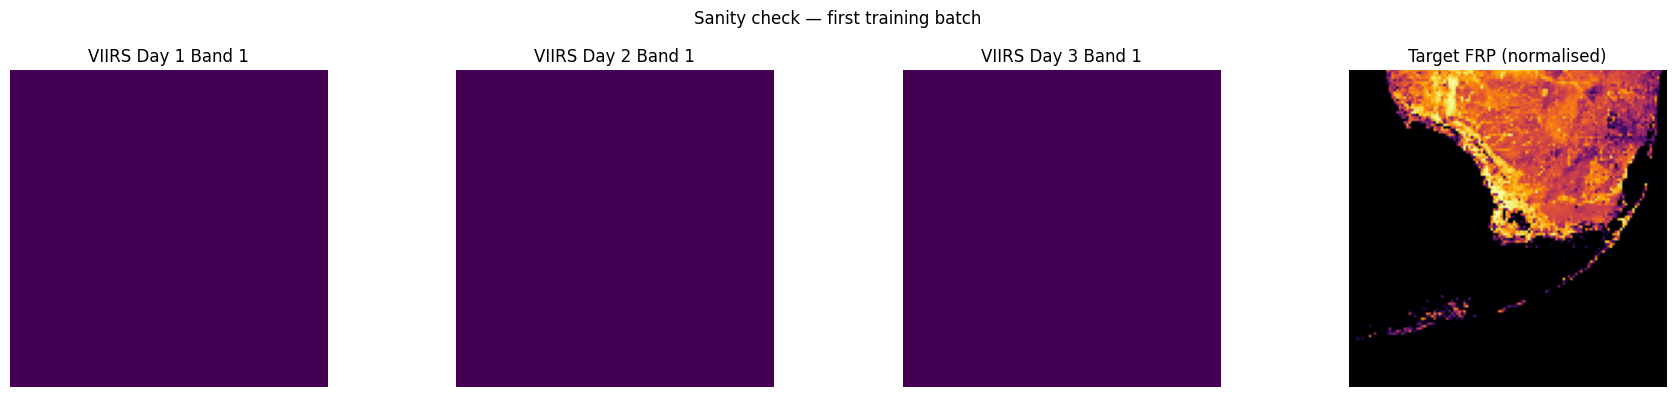

If the target image shows bright spots = fire areas, the pipeline is correct.


In [6]:
class SatFireDataset(Dataset):
    """
    Loads SEQ_LEN consecutive days of VIIRS thermal + ESRI LULC as input,
    and the next day's FirePred Band-1 (FRP) raster as the regression target.

    Band assignments confirmed by diagnostic scan:
        VIIRS_Day   : 8 bands  (always consistent across all 3031 files)
        VIIRS_Night : 2 bands  (always consistent across 99.7% of files)
        FirePred    : 19 bands — Band 1 is FRP (Fire Radiative Power, mW/m2)
                      Bands 3-9, 13, 19 are NaN/zero — ignored.

    Each item returned:
        viirs  : Tensor [SEQ_LEN, C_viirs, H, W]  -- normalised to [0, 1]
        lulc   : Tensor [H, W]                    -- integer class labels
        target : Tensor [1, H, W]                 -- fire probability [0, 1]
    """

    # Physical FRP range for normalisation:
    # Negative values = background noise -> clipped to 0
    # 99th-percentile of positive values used as upper bound per sample
    FIREPRED_BAND = 1     # Band 1 = FRP signal

    def __init__(
        self,
        event_dirs,
        spatial_size:    int   = SPATIAL_SIZE,
        seq_len:         int   = SEQ_LEN,
        use_night:       bool  = USE_NIGHT,
        viirs_channels:  int   = VIIRS_CHANNELS,
        night_channels:  int   = NIGHT_CHANNELS,
        viirs_clip_min:  float = VIIRS_CLIP_MIN,
        viirs_clip_max:  float = VIIRS_CLIP_MAX,
    ):
        self.event_dirs    = event_dirs
        self.spatial_size  = (spatial_size, spatial_size)
        self.seq_len       = seq_len
        self.use_night     = use_night
        self.viirs_ch      = viirs_channels   # 8  — day bands
        self.night_ch      = night_channels   # 2  — night bands
        self.viirs_min     = viirs_clip_min
        self.viirs_max     = viirs_clip_max

    # ── helpers ──────────────────────────────────────────────────────────────
    @staticmethod
    def _read_tif_band(path: str, band: int = 1) -> np.ndarray:
        """Read a specific band (1-indexed) as float32, NaN -> 0."""
        with rasterio.open(path) as src:
            arr = src.read(band).astype(np.float32)
        return np.nan_to_num(arr, nan=0.0)

    @staticmethod
    def _read_tif_all(path: str) -> np.ndarray:
        """Read all bands as float32 [C, H, W], NaN -> 0."""
        with rasterio.open(path) as src:
            arr = src.read().astype(np.float32)
        return np.nan_to_num(arr, nan=0.0)

    def _normalise_viirs(self, arr: np.ndarray) -> np.ndarray:
        """Clip to physical BT range then scale to [0, 1]."""
        arr = np.clip(arr, self.viirs_min, self.viirs_max)
        return (arr - self.viirs_min) / (self.viirs_max - self.viirs_min)

    def _normalise_frp(self, arr: np.ndarray) -> np.ndarray:
        """
        Normalise FRP (Fire Radiative Power):
          - Clip negatives to 0  (negative = sensor noise, not fire)
          - Scale by 99th percentile of positive pixels, or 1.0 if no fire
        Result is in [0, 1].
        """
        arr = np.clip(arr, 0.0, None)          # remove negative noise
        positives = arr[arr > 0]
        if len(positives) == 0:
            return arr                          # all-zero map (no fire day)
        p99 = float(np.percentile(positives, 99))
        p99 = max(p99, 1.0)                    # avoid division by zero
        return np.clip(arr / p99, 0.0, 1.0)

    def _fix_channels(self, arr: np.ndarray, target_c: int) -> np.ndarray:
        """Force [C, H, W] to exactly target_c channels (trim or zero-pad)."""
        c = arr.shape[0]
        if c == target_c:
            return arr
        if c > target_c:
            return arr[:target_c]
        pad = np.zeros((target_c - c, arr.shape[1], arr.shape[2]), dtype=arr.dtype)
        return np.concatenate([arr, pad], axis=0)

    def _resize_bands(self, arr: np.ndarray) -> np.ndarray:
        """Resize [C, H, W] to [C, S, S] via bilinear interpolation."""
        t = torch.tensor(arr, dtype=torch.float32).unsqueeze(0)
        t = F.interpolate(t, size=self.spatial_size, mode="bilinear", align_corners=False)
        return t.squeeze(0).numpy()

    # ── dataset interface ─────────────────────────────────────────────────────
    def __len__(self):
        return len(self.event_dirs)

    def __getitem__(self, idx):
        event_path = self.event_dirs[idx]

        # ── 1. Collect and sort file lists ────────────────────────────────────
        day_files   = sorted(glob.glob(os.path.join(event_path, "VIIRS_Day",   "*.tif")))
        fire_files  = sorted(glob.glob(os.path.join(event_path, "FirePred",    "*.tif")))
        night_files = sorted(glob.glob(os.path.join(event_path, "VIIRS_Night", "*.tif")))

        n_avail = min(len(day_files), len(fire_files))
        if n_avail < self.seq_len + 1:
            raise ValueError(
                f"Event {event_path} has only {n_avail} dates; "
                f"need {self.seq_len + 1}."
            )

        input_day_files  = day_files[:self.seq_len]
        target_fire_file = fire_files[self.seq_len]   # Day N+1 target

        # ── 2. Load VIIRS_Day frames ──────────────────────────────────────────
        # Pipeline: read -> normalise BT -> enforce 8 channels -> resize to S×S
        viirs_frames = []
        for f in input_day_files:
            bands = self._read_tif_all(f)             # [C, H, W]
            bands = self._normalise_viirs(bands)
            bands = self._fix_channels(bands, self.viirs_ch)   # always 8
            bands = self._resize_bands(bands)                   # [8, S, S]
            viirs_frames.append(bands)

        # ── 3. Fuse VIIRS_Night (2 bands per file) ────────────────────────────
        # Night files have 2 bands. Missing files get zero-filled.
        if self.use_night:
            fused = []
            for t, day_arr in enumerate(viirs_frames):
                if t < len(night_files):
                    n_arr = self._read_tif_all(night_files[t])
                    n_arr = self._normalise_viirs(n_arr)
                    n_arr = self._fix_channels(n_arr, self.night_ch)  # always 2
                    n_arr = self._resize_bands(n_arr)                  # [2, S, S]
                else:
                    n_arr = np.zeros((self.night_ch,) + self.spatial_size,
                                     dtype=np.float32)
                fused.append(np.concatenate([day_arr, n_arr], axis=0))  # [10, S, S]
            viirs_frames = fused

        # All frames: identical shape [C, S, S] — stack is always safe
        viirs_seq = np.stack(viirs_frames, axis=0)   # [T, C, S, S]

        # ── 4. Load ESRI LULC ─────────────────────────────────────────────────
        lulc_files = glob.glob(os.path.join(event_path, "ESRI_LULC", "*.tif"))
        if len(lulc_files) == 0:
            lulc = np.zeros(self.spatial_size, dtype=np.float32)
        else:
            lulc = self._read_tif_band(lulc_files[0], band=1)

        # ── 5. Load target — FirePred Band 1 (FRP) ────────────────────────────
        # Band 1 = Fire Radiative Power (mW/m2).
        # Negatives = sensor noise, clipped to 0.
        # Normalised to [0, 1] using 99th-percentile of positive pixels.
        target = self._read_tif_band(target_fire_file, band=self.FIREPRED_BAND)
        target = self._normalise_frp(target)

        # ── 6. Convert to tensors ─────────────────────────────────────────────
        viirs_t  = torch.tensor(viirs_seq, dtype=torch.float32)
        lulc_t   = torch.tensor(lulc,      dtype=torch.long)
        target_t = torch.tensor(target,    dtype=torch.float32).unsqueeze(0)

        # ── 7. Resize target and LULC to spatial_size ────────────────────────
        target_t = F.interpolate(
            target_t.unsqueeze(0), size=self.spatial_size,
            mode="bilinear", align_corners=False
        ).squeeze(0)

        lulc_t = lulc_t.unsqueeze(0).unsqueeze(0).float()
        lulc_t = F.interpolate(lulc_t, size=self.spatial_size, mode="nearest")
        lulc_t = lulc_t.squeeze().long().clamp(0, LULC_CLASSES - 1)

        return viirs_t, lulc_t, target_t


# ─── Scan & filter valid events ───────────────────────────────────────────────
print("Scanning dataset for valid events ...")

valid_dirs   = []
skipped_lulc = 0
for d in all_event_dirs:
    day_f  = glob.glob(os.path.join(d, "VIIRS_Day",  "*.tif"))
    fire_f = glob.glob(os.path.join(d, "FirePred",   "*.tif"))
    lulc_f = glob.glob(os.path.join(d, "ESRI_LULC",  "*.tif"))
    if len(lulc_f) == 0:
        skipped_lulc += 1
        continue
    if len(day_f) >= SEQ_LEN + 1 and len(fire_f) >= SEQ_LEN + 1:
        valid_dirs.append(d)

n_total = len(valid_dirs)
n_train = int(SPLIT_TRAIN * n_total)
n_val   = int(SPLIT_VAL   * n_total)
n_test  = n_total - n_train - n_val

generator = torch.Generator().manual_seed(SEED)
train_dirs, val_dirs, test_dirs = random_split(
    valid_dirs, [n_train, n_val, n_test], generator=generator
)
train_dirs = [valid_dirs[i] for i in train_dirs.indices]
val_dirs   = [valid_dirs[i] for i in val_dirs.indices]
test_dirs  = [valid_dirs[i] for i in test_dirs.indices]

ds_kwargs    = dict(spatial_size=SPATIAL_SIZE, seq_len=SEQ_LEN, use_night=USE_NIGHT)
train_ds     = SatFireDataset(train_dirs, **ds_kwargs)
val_ds       = SatFireDataset(val_dirs,   **ds_kwargs)
test_ds      = SatFireDataset(test_dirs,  **ds_kwargs)

loader_kwargs = dict(num_workers=0, pin_memory=False)
train_loader  = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  **loader_kwargs)
val_loader    = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, **loader_kwargs)
test_loader   = DataLoader(test_ds,  batch_size=1,          shuffle=False, **loader_kwargs)

print(f"Valid events  : {n_total}  (skipped {skipped_lulc} without ESRI_LULC)")
print(f"   Train      : {len(train_ds)}")
print(f"   Validation : {len(val_ds)}")
print(f"   Test       : {len(test_ds)}")

viirs_b, lulc_b, tgt_b = next(iter(train_loader))
C_VIIRS = viirs_b.shape[2]
print(f"\nSample batch shapes:")
print(f"  viirs  : {tuple(viirs_b.shape)}  (B, T, C, H, W)  C={C_VIIRS} = {VIIRS_CHANNELS} day + {NIGHT_CHANNELS if USE_NIGHT else 0} night")
print(f"  lulc   : {tuple(lulc_b.shape)}   (B, H, W)")
print(f"  target : {tuple(tgt_b.shape)}    (B, 1, H, W)")
print(f"  target range : [{tgt_b.min():.4f}, {tgt_b.max():.4f}]  (should be [0, 1])")

# Quick sanity — visualise one target to confirm it shows fire structure
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle("Sanity check — first training batch", fontsize=12)
axes[0].imshow(viirs_b[0, 0, 0].numpy(), cmap="viridis"); axes[0].set_title("VIIRS Day 1 Band 1")
axes[1].imshow(viirs_b[0, 1, 0].numpy(), cmap="viridis"); axes[1].set_title("VIIRS Day 2 Band 1")
axes[2].imshow(viirs_b[0, 2, 0].numpy(), cmap="viridis"); axes[2].set_title("VIIRS Day 3 Band 1")
axes[3].imshow(tgt_b[0, 0].numpy(), cmap="inferno");      axes[3].set_title("Target FRP (normalised)")
for ax in axes: ax.axis("off")
plt.tight_layout()
plt.show()
print("If the target image shows bright spots = fire areas, the pipeline is correct.")


## 4b. Preprocess & Cache Dataset to Disk
Run **once** — saves every sample as a `.pt` file. Training then uses `CachedFireDataset` which loads in ~10ms instead of ~2s per sample, cutting total training time from ~8 hours to ~15-20 minutes.

In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
# PREPROCESSING CACHE
# Converts every raw event into a pre-normalised, pre-resized .pt file.
# Run ONCE. Training will then use CachedFireDataset which loads in ~10ms
# per sample instead of ~1-2s for raw rasterio reads.
# ═══════════════════════════════════════════════════════════════════════════════
import os, glob, time
import numpy as np
import torch
import torch.nn.functional as F
import rasterio
from tqdm.auto import tqdm

CACHE_DIR = os.path.join(SAVE_DIR, "cache")
os.makedirs(CACHE_DIR, exist_ok=True)

# ── Reuse helpers from SatFireDataset ────────────────────────────────────────
def _read_tif_band(path, band=1):
    with rasterio.open(path) as src:
        arr = src.read(band).astype(np.float32)
    return np.nan_to_num(arr, nan=0.0)

def _read_tif_all(path):
    with rasterio.open(path) as src:
        arr = src.read().astype(np.float32)
    return np.nan_to_num(arr, nan=0.0)

def _normalise_viirs(arr):
    """Per-band min-max normalisation to [0, 1]."""
    out = np.zeros_like(arr, dtype=np.float32)
    for i in range(arr.shape[0]):
        b = arr[i]
        bmin, bmax = b.min(), b.max()
        if bmax - bmin > 1e-6:
            out[i] = (b - bmin) / (bmax - bmin)
    return out

def _normalise_frp(arr):
    """Clip negatives, scale by 99th-percentile of positive pixels."""
    arr = np.clip(arr, 0.0, None)
    pos = arr[arr > 0]
    if len(pos) == 0:
        return arr
    p99 = max(float(np.percentile(pos, 99)), 1.0)
    return np.clip(arr / p99, 0.0, 1.0)

def _fix_channels(arr, target_c):
    c = arr.shape[0]
    if c == target_c: return arr
    if c > target_c:  return arr[:target_c]
    pad = np.zeros((target_c - c, arr.shape[1], arr.shape[2]), dtype=arr.dtype)
    return np.concatenate([arr, pad], axis=0)

def _resize(arr, size):
    """Resize [C, H, W] numpy → [C, S, S] tensor via bilinear."""
    t = torch.tensor(arr, dtype=torch.float32).unsqueeze(0)
    t = F.interpolate(t, size=size, mode="bilinear", align_corners=False)
    return t.squeeze(0)   # returns torch.Tensor [C, S, S]

def preprocess_event(event_path):
    """
    Preprocess one event directory into a dict of tensors.
    Returns None if the event doesn't have enough dates.
    """
    S = (SPATIAL_SIZE, SPATIAL_SIZE)

    day_files   = sorted(glob.glob(os.path.join(event_path, "VIIRS_Day",   "*.tif")))
    fire_files  = sorted(glob.glob(os.path.join(event_path, "FirePred",    "*.tif")))
    night_files = sorted(glob.glob(os.path.join(event_path, "VIIRS_Night", "*.tif")))
    lulc_files  = glob.glob(os.path.join(event_path, "ESRI_LULC", "*.tif"))

    n_avail = min(len(day_files), len(fire_files))
    n_pairs = n_avail - SEQ_LEN   # how many (input_seq, target) pairs we can make

    if n_pairs < 1 or len(lulc_files) == 0:
        return []

    # ── LULC — static, load once ─────────────────────────────────────────────
    lulc_raw = _read_tif_band(lulc_files[0], band=1)
    lulc_t   = torch.tensor(lulc_raw, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
    lulc_t   = F.interpolate(lulc_t, size=S, mode="nearest").squeeze().long()
    lulc_t   = lulc_t.clamp(0, LULC_CLASSES - 1)

    samples = []

    # Slide a window of (SEQ_LEN input days + 1 target day) across all dates
    for start in range(n_pairs):
        input_days   = day_files[start : start + SEQ_LEN]
        target_file  = fire_files[start + SEQ_LEN]

        # ── VIIRS day frames ──────────────────────────────────────────────────
        viirs_frames = []
        for f in input_days:
            bands = _normalise_viirs(_read_tif_all(f))
            bands = _fix_channels(bands, VIIRS_CHANNELS)
            frame = _resize(bands, S)                      # [8, S, S] tensor
            viirs_frames.append(frame)

        # ── Fuse VIIRS_Night ──────────────────────────────────────────────────
        if USE_NIGHT:
            fused = []
            for t_idx, day_t in enumerate(viirs_frames):
                night_idx = start + t_idx
                if night_idx < len(night_files):
                    n_arr = _normalise_viirs(_read_tif_all(night_files[night_idx]))
                    n_arr = _fix_channels(n_arr, NIGHT_CHANNELS)
                    n_t   = _resize(n_arr, S)              # [2, S, S] tensor
                else:
                    n_t = torch.zeros(NIGHT_CHANNELS, *S)
                fused.append(torch.cat([day_t, n_t], dim=0))   # [10, S, S]
            viirs_frames = fused

        viirs_t = torch.stack(viirs_frames, dim=0)             # [T, C, S, S]

        # ── Target ────────────────────────────────────────────────────────────
        tgt_raw = _read_tif_band(target_file, band=1)
        tgt_raw = _normalise_frp(tgt_raw)
        tgt_t   = torch.tensor(tgt_raw, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
        tgt_t   = F.interpolate(tgt_t, size=S, mode="bilinear",
                                align_corners=False).squeeze(0)   # [1, S, S]

        samples.append({
            "viirs" : viirs_t,   # [T, C, S, S]
            "lulc"  : lulc_t,   # [S, S]
            "target": tgt_t,    # [1, S, S]
        })

    return samples


# ═══════════════════════════════════════════════════════════════════════════════
# MAIN PREPROCESSING LOOP
# ═══════════════════════════════════════════════════════════════════════════════
print(f"Cache directory : {CACHE_DIR}")
print(f"Spatial size    : {SPATIAL_SIZE}×{SPATIAL_SIZE}")
print(f"Sequence length : {SEQ_LEN} input days + 1 target")
print(f"Night fusion    : {USE_NIGHT}")
print()

# Check how many are already cached
already_cached = len(glob.glob(os.path.join(CACHE_DIR, "*.pt")))
if already_cached > 0:
    print(f"Found {already_cached} cached samples already.")
    resp = input("Re-generate cache? (y/n, default=n): ").strip().lower()
    if resp != "y":
        print("Skipping preprocessing — using existing cache.")
        # Just count and report
        cache_files = sorted(glob.glob(os.path.join(CACHE_DIR, "*.pt")))
        print(f"Total cached samples : {len(cache_files)}")
        # Load one to confirm shape
        sample = torch.load(cache_files[0], weights_only=True)
        print(f"Sample shapes  viirs={tuple(sample['viirs'].shape)}  "
              f"lulc={tuple(sample['lulc'].shape)}  "
              f"target={tuple(sample['target'].shape)}")
        raise SystemExit("Cache already exists — proceed to Cell 4c.")

t0 = time.time()
total_samples = 0
errors = 0

for event_path in tqdm(all_event_dirs, desc="Preprocessing events"):
    try:
        samples = preprocess_event(event_path)
        for s_idx, sample in enumerate(samples):
            event_name = os.path.basename(event_path)
            fname = f"{event_name}_seq{s_idx:03d}.pt"
            torch.save(sample, os.path.join(CACHE_DIR, fname))
            total_samples += 1
    except Exception as e:
        errors += 1

elapsed = time.time() - t0
cache_size_mb = sum(
    os.path.getsize(f) for f in glob.glob(os.path.join(CACHE_DIR, "*.pt"))
) / 1e6

print(f"\n✅ Preprocessing complete")
print(f"   Total samples cached : {total_samples}")
print(f"   Errors skipped       : {errors}")
print(f"   Time elapsed         : {elapsed/60:.1f} min")
print(f"   Cache size on disk   : {cache_size_mb:.1f} MB")

# Verify one sample
sample_files = sorted(glob.glob(os.path.join(CACHE_DIR, "*.pt")))
s = torch.load(sample_files[0], weights_only=True)
print(f"\nSample shapes:")
print(f"  viirs  : {tuple(s['viirs'].shape)}")
print(f"  lulc   : {tuple(s['lulc'].shape)}")
print(f"  target : {tuple(s['target'].shape)}")
print(f"  target range: [{s['target'].min():.4f}, {s['target'].max():.4f}]")


Cache directory : /kaggle/working/cache
Spatial size    : 128×128
Sequence length : 3 input days + 1 target
Night fusion    : True



Preprocessing events:   0%|          | 0/192 [00:00<?, ?it/s]


✅ Preprocessing complete
   Total samples cached : 2581
   Errors skipped       : 0
   Time elapsed         : 51.5 min
   Cache size on disk   : 5587.7 MB

Sample shapes:
  viirs  : (3, 10, 128, 128)
  lulc   : (128, 128)
  target : (1, 128, 128)
  target range: [0.0008, 1.0000]


In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
# CACHED DATASET CLASS  — replaces SatFireDataset for training
# Loads pre-processed .pt files directly — no rasterio, no resizing, ~10ms/sample
# ═══════════════════════════════════════════════════════════════════════════════
from torch.utils.data import Dataset, DataLoader, random_split

class CachedFireDataset(Dataset):
    """Loads pre-processed .pt files. Each file is one (viirs, lulc, target) sample."""

    def __init__(self, cache_files):
        self.files = cache_files

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        s = torch.load(self.files[idx], weights_only=True)
        return s["viirs"], s["lulc"], s["target"]


# ── Split cache files into train / val / test ─────────────────────────────────
all_cache_files = sorted(glob.glob(os.path.join(CACHE_DIR, "*.pt")))
print(f"Total cached samples : {len(all_cache_files)}")

n_total = len(all_cache_files)
n_train = int(SPLIT_TRAIN * n_total)
n_val   = int(SPLIT_VAL   * n_total)
n_test  = n_total - n_train - n_val

generator = torch.Generator().manual_seed(SEED)
idx_splits = random_split(range(n_total), [n_train, n_val, n_test], generator=generator)

train_files = [all_cache_files[i] for i in idx_splits[0]]
val_files   = [all_cache_files[i] for i in idx_splits[1]]
test_files  = [all_cache_files[i] for i in idx_splits[2]]

train_ds = CachedFireDataset(train_files)
val_ds   = CachedFireDataset(val_files)
test_ds  = CachedFireDataset(test_files)

# num_workers=2 is now safe — .pt loads are lightweight and don't use rasterio
loader_kwargs = dict(num_workers=0, pin_memory=False)  # 0 avoids multiprocessing teardown errors on Kaggle
train_loader  = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  **loader_kwargs)
val_loader    = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, **loader_kwargs)
test_loader   = DataLoader(test_ds,  batch_size=1,          shuffle=False, **loader_kwargs)

print(f"   Train      : {len(train_ds)}")
print(f"   Validation : {len(val_ds)}")
print(f"   Test       : {len(test_ds)}")

# ── Shape check + timing benchmark ───────────────────────────────────────────
import time
viirs_b, lulc_b, tgt_b = next(iter(train_loader))
C_VIIRS = viirs_b.shape[2]

print(f"\nBatch shapes:")
print(f"  viirs  : {tuple(viirs_b.shape)}")
print(f"  lulc   : {tuple(lulc_b.shape)}")
print(f"  target : {tuple(tgt_b.shape)}")

# Time 10 batches to confirm speedup
t0 = time.time()
for i, _ in enumerate(train_loader):
    if i >= 9: break
t_per_batch = (time.time() - t0) / 10
print(f"\nAverage time per batch : {t_per_batch:.3f}s  (was ~22s with raw loader)")
print(f"Estimated time per epoch (train only) : {t_per_batch * len(train_loader) / 60:.1f} min")
print(f"Estimated total training ({EPOCHS} epochs) : {t_per_batch * (len(train_loader) + len(val_loader)) * EPOCHS / 3600:.2f} hours")


Total cached samples : 2581
   Train      : 1806
   Validation : 387
   Test       : 388

Batch shapes:
  viirs  : (2, 3, 10, 128, 128)
  lulc   : (2, 128, 128)
  target : (2, 1, 128, 128)

Average time per batch : 0.059s  (was ~22s with raw loader)
Estimated time per epoch (train only) : 0.9 min
Estimated total training (20 epochs) : 0.36 hours


## 5. Model Architecture

In [9]:
# ═══════════════════════════════════════════════════════════════════════════════
# 5.1  Building Blocks
# ═══════════════════════════════════════════════════════════════════════════════

class ConvBNReLU(nn.Module):
    """Conv2d → BatchNorm → ReLU."""
    def __init__(self, in_ch, out_ch, kernel=3, stride=1, padding=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel, stride=stride, padding=padding, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)


class ResidualCNNBlock(nn.Module):
    """Double-conv residual block with optional channel projection."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            ConvBNReLU(in_ch, out_ch),
            ConvBNReLU(out_ch, out_ch),
        )
        self.skip = (
            nn.Conv2d(in_ch, out_ch, kernel_size=1, bias=False)
            if in_ch != out_ch else nn.Identity()
        )

    def forward(self, x):
        return F.relu(self.conv(x) + self.skip(x), inplace=True)


# ═══════════════════════════════════════════════════════════════════════════════
# 5.2  Spatial Encoder  (per-frame CNN with skip-connection outputs)
# ═══════════════════════════════════════════════════════════════════════════════

class SpatialEncoder(nn.Module):
    """
    Processes each day-frame independently.
    Returns per-frame feature maps at three scales for the UNet decoder,
    plus the bottleneck token map used by the Transformer.

    Input  : [B*T, C_in, H, W]
    Outputs:
        s1  — [B*T, 32,        H/2,  W/2 ]
        s2  — [B*T, 64,        H/4,  W/4 ]
        s3  — [B*T, embed_dim, H/8,  W/8 ]  ← transformer input
    """

    def __init__(self, viirs_channels: int, lulc_embed_dim: int, embed_dim: int):
        super().__init__()
        in_ch = viirs_channels + lulc_embed_dim

        self.enc1  = ResidualCNNBlock(in_ch,    32)
        self.pool1 = nn.MaxPool2d(2, 2)

        self.enc2  = ResidualCNNBlock(32,        64)
        self.pool2 = nn.MaxPool2d(2, 2)

        self.enc3  = ResidualCNNBlock(64,        embed_dim)
        self.pool3 = nn.MaxPool2d(2, 2)

    def forward(self, x):
        s1 = self.enc1(x)               # [BT, 32, H/2,  W/2 ]
        s2 = self.enc2(self.pool1(s1))  # [BT, 64, H/4,  W/4 ]
        s3 = self.enc3(self.pool2(s2))  # [BT, D,  H/8,  W/8 ]
        bt = self.pool3(s3)             # [BT, D,  H/16, W/16]
        return s1, s2, s3, bt


# ═══════════════════════════════════════════════════════════════════════════════
# 5.3  Spatiotemporal Transformer
# ═══════════════════════════════════════════════════════════════════════════════

class SpatiotemporalTransformer(nn.Module):
    """
    Treats every (spatial token, temporal step) tuple as a sequence element.
    Separate learnable positional embeddings for spatial location and time-step
    are added before the encoder stack.

    Input  : [B, T, D, Hf, Wf]
    Output : [B, T, D, Hf, Wf]
    """

    def __init__(self, embed_dim, num_heads, num_layers, seq_len,
                 spatial_size_after_enc, dropout):
        super().__init__()
        Hf = Wf = spatial_size_after_enc // 8    # after 3× pooling in encoder
        self.Hf, self.Wf = Hf, Wf
        n_spatial = Hf * Wf

        # Learnable 2D spatial positional embedding
        self.spatial_pos = nn.Parameter(torch.randn(1, 1, n_spatial, embed_dim) * 0.02)
        # Learnable temporal positional embedding
        self.temporal_pos = nn.Parameter(torch.randn(1, seq_len, 1, embed_dim) * 0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads,
            dim_feedforward=embed_dim * 4,
            dropout=dropout, activation="gelu", batch_first=True,
            norm_first=True,   # Pre-LN: more stable training
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm        = nn.LayerNorm(embed_dim)

    def forward(self, x):
        B, T, D, H, W = x.shape
        # Flatten spatial dims: [B, T, HW, D]
        x = x.view(B, T, D, H * W).permute(0, 1, 3, 2)
        # Add positional embeddings
        x = x + self.spatial_pos + self.temporal_pos
        # Merge T and spatial dims into one sequence: [B, T*HW, D]
        x = x.reshape(B, T * H * W, D)
        x = self.transformer(x)
        x = self.norm(x)
        # Restore: [B, T, D, H, W]
        x = x.view(B, T, H * W, D).permute(0, 1, 3, 2).contiguous()
        return x.view(B, T, D, H, W)


# ═══════════════════════════════════════════════════════════════════════════════
# 5.4  Temporal Attention Pooling
# ═══════════════════════════════════════════════════════════════════════════════

class TemporalAttentionPooling(nn.Module):
    """
    Learns per-pixel temporal importance weights to collapse T → 1.

    Input  : [B, T, D, H, W]
    Output : pooled [B, D, H, W],  weights [B, T]
    """

    def __init__(self, embed_dim):
        super().__init__()
        self.score_net = nn.Sequential(
            nn.Conv2d(embed_dim, embed_dim // 2, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(embed_dim // 2, 1, 1),
        )

    def forward(self, x):
        B, T, D, H, W = x.shape
        # Compute a scalar score per (frame, spatial position)
        scores = self.score_net(x.view(B * T, D, H, W))   # [BT, 1, H, W]
        scores = scores.view(B, T, H * W).mean(dim=2)     # [B, T]
        weights = F.softmax(scores, dim=1)                # [B, T]

        # Weighted sum over time
        w = weights.view(B, T, 1, 1, 1)
        pooled = (x * w).sum(dim=1)                       # [B, D, H, W]
        return pooled, weights


# ═══════════════════════════════════════════════════════════════════════════════
# 5.5  UNet-style Decoder with Skip Connections
# ═══════════════════════════════════════════════════════════════════════════════

class UNetDecoder(nn.Module):
    """
    Three-stage transposed-conv upsampler.
    At each stage, skip features from the corresponding encoder level
    are concatenated before the refinement convolution.

    Input  : bottleneck [B, D, H/8, W/8] + skips from SpatialEncoder
    Output : [B, 1, H, W]  (fire probability logit, passed through sigmoid)
    """

    def __init__(self, embed_dim: int = 128):
        super().__init__()
        # Up-stages: each doubles spatial resolution
        self.up3 = nn.Sequential(
            nn.ConvTranspose2d(embed_dim, 64, 4, stride=2, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
        )
        self.refine3 = ResidualCNNBlock(64 + embed_dim, 64)   # +skip from enc3

        self.up2 = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
        )
        self.refine2 = ResidualCNNBlock(32 + 64, 32)          # +skip from enc2

        self.up1 = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 4, stride=2, padding=1),
            nn.BatchNorm2d(16), nn.ReLU(inplace=True),
        )
        self.refine1 = ResidualCNNBlock(16 + 32, 16)          # +skip from enc1

        self.head = nn.Conv2d(16, 1, kernel_size=1)

    def forward(self, bottleneck, s3_agg, s2_agg, s1_agg):
        x = self.up3(bottleneck)
        x = self.refine3(torch.cat([x, s3_agg], dim=1))

        x = self.up2(x)
        x = self.refine2(torch.cat([x, s2_agg], dim=1))

        x = self.up1(x)
        x = self.refine1(torch.cat([x, s1_agg], dim=1))

        return torch.sigmoid(self.head(x))     # [B, 1, H, W] ∈ [0, 1]


# ═══════════════════════════════════════════════════════════════════════════════
# 5.6  Full DeepFire Model
# ═══════════════════════════════════════════════════════════════════════════════

class DeepFireForecaster(nn.Module):
    """
    Full end-to-end pipeline:
        1. LULC embedding lookup
        2. Per-frame Spatial CNN Encoder (shared weights)
        3. Spatiotemporal Transformer
        4. Temporal Attention Pooling
        5. UNet Decoder with skip connections
    """

    def __init__(
        self,
        viirs_channels:  int   = VIIRS_CHANNELS * (2 if USE_NIGHT else 1),
        lulc_classes:    int   = LULC_CLASSES,
        lulc_embed_dim:  int   = LULC_EMBED_DIM,
        embed_dim:       int   = EMBED_DIM,
        num_heads:       int   = NUM_HEADS,
        num_layers:      int   = NUM_LAYERS,
        seq_len:         int   = SEQ_LEN,
        spatial_size:    int   = SPATIAL_SIZE,
        dropout:         float = DROPOUT,
    ):
        super().__init__()
        self.seq_len = seq_len

        # ── 1. LULC embedding ─────────────────────────────────────────────────
        self.lulc_embed = nn.Embedding(lulc_classes, lulc_embed_dim)

        # ── 2. Spatial encoder (weights shared across all T frames) ───────────
        self.spatial_encoder = SpatialEncoder(viirs_channels, lulc_embed_dim, embed_dim)

        # ── 3. Spatiotemporal transformer ─────────────────────────────────────
        self.transformer = SpatiotemporalTransformer(
            embed_dim, num_heads, num_layers, seq_len, spatial_size, dropout
        )

        # ── 4. Temporal attention pooling ─────────────────────────────────────
        self.temporal_pool = TemporalAttentionPooling(embed_dim)

        # ── 5. UNet decoder ───────────────────────────────────────────────────
        self.decoder = UNetDecoder(embed_dim)

    def forward(self, viirs, lulc):
        """
        viirs : [B, T, C, H, W]
        lulc  : [B, H, W]       — integer class labels
        returns:
            pred         : [B, 1, H, W]  fire probability map
            attn_weights : [B, T]        temporal importance per day
        """
        B, T, C, H, W = viirs.shape

        # ── LULC embedding → spatial map ──────────────────────────────────────
        lulc_emb = self.lulc_embed(lulc)                    # [B, H, W, E]
        lulc_emb = lulc_emb.permute(0, 3, 1, 2)            # [B, E, H, W]

        # ── Spatial encoder: process each frame with shared weights ───────────
        # Broadcast LULC to every temporal frame
        lulc_rep = lulc_emb.unsqueeze(1).expand(-1, T, -1, -1, -1)  # [B, T, E, H, W]
        viirs_flat   = viirs.view(B * T, C, H, W)
        lulc_flat    = lulc_rep.reshape(B * T, LULC_EMBED_DIM, H, W)

        x_in = torch.cat([viirs_flat, lulc_flat], dim=1)   # [BT, C+E, H, W]
        s1, s2, s3, bottleneck = self.spatial_encoder(x_in)

        # Restore temporal axis
        def _reshape(t, ch, h, w):
            return t.view(B, T, ch, h, w)

        _, _, H3, W3 = s3.shape
        _, _, H2, W2 = s2.shape
        _, _, H1, W1 = s1.shape
        _, D,  Hb, Wb = bottleneck.shape

        bt_seq  = _reshape(bottleneck, D,  Hb, Wb)         # [B, T, D, Hb, Wb]

        # ── Transformer ───────────────────────────────────────────────────────
        bt_seq  = self.transformer(bt_seq)                  # [B, T, D, Hb, Wb]

        # ── Temporal pooling ──────────────────────────────────────────────────
        pooled, attn_weights = self.temporal_pool(bt_seq)   # [B, D, Hb, Wb]

        # Aggregate skip features by averaging across T
        s3_agg = _reshape(s3, s3.shape[1], H3, W3).mean(dim=1)
        s2_agg = _reshape(s2, s2.shape[1], H2, W2).mean(dim=1)
        s1_agg = _reshape(s1, s1.shape[1], H1, W1).mean(dim=1)

        # ── Decoder ───────────────────────────────────────────────────────────
        pred = self.decoder(pooled, s3_agg, s2_agg, s1_agg)

        return pred, attn_weights


# ─── Instantiate & print parameter count ─────────────────────────────────────
# C_VIIRS is auto-detected from the actual dataloader output (Cell 5).
# Night fusion may be skipped for events with missing night files, so
# C_VIIRS can differ from VIIRS_CHANNELS*2. Passing it explicitly ensures
# the encoder input_channels always matches the real tensor.
model = DeepFireForecaster(viirs_channels=C_VIIRS).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"✅ DeepFireForecaster initialised")
print(f"   Total parameters     : {total_params:,}")
print(f"   Trainable parameters : {trainable:,}")

# ─── Dry-run to verify shapes ─────────────────────────────────────────────────
with torch.no_grad():
    dummy_viirs = torch.randn(2, SEQ_LEN, C_VIIRS, SPATIAL_SIZE, SPATIAL_SIZE).to(DEVICE)
    dummy_lulc  = torch.randint(0, LULC_CLASSES, (2, SPATIAL_SIZE, SPATIAL_SIZE)).to(DEVICE)
    pred, w     = model(dummy_viirs, dummy_lulc)
    print(f"   Dry-run output shape : {tuple(pred.shape)}  ✓")
    print(f"   Attn weights shape   : {tuple(w.shape)}  ✓")


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


✅ DeepFireForecaster initialised
   Total parameters     : 1,321,730
   Trainable parameters : 1,321,730
   Dry-run output shape : (2, 1, 128, 128)  ✓
   Attn weights shape   : (2, 3)  ✓


## 6. Masked Focal-Dice Loss

In [11]:
class MaskedFocalDiceLoss(nn.Module):
    """
    Combines two components designed for severe class imbalance:

    • Focal Loss   — down-weights the large mass of easy background pixels,
                     forcing the network to focus on rare fire pixels.
    • Dice Loss    — directly optimises the overlap coefficient, robust to
                     imbalanced class frequencies.

    A validity mask derived from the target (>= 0 and not NaN) ensures that
    padded or no-data regions do not contribute to the gradient.

    Args:
        gamma       : Focal modulating exponent (2.0 is standard).
        alpha       : Weight on fire-positive class.
        dice_weight : Blend coefficient (1 = all Dice, 0 = all Focal).
    """

    def __init__(
        self,
        gamma:       float = FOCAL_GAMMA,
        alpha:       float = FOCAL_ALPHA,
        dice_weight: float = DICE_WEIGHT,
        eps:         float = 1e-6,
    ):
        super().__init__()
        self.gamma       = gamma
        self.alpha       = alpha
        self.dice_weight = dice_weight
        self.eps         = eps

    def forward(self, pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        """
        pred   : [B, 1, H, W]  probabilities in [0, 1]  (after sigmoid)
        target : [B, 1, H, W]  ground-truth in [0, 1]
        """
        # ── Validity mask: ignore NaNs and out-of-range pixels ────────────────
        mask = (~torch.isnan(target)) & (target >= 0.0) & (target <= 1.0)
        mask = mask.float()

        p   = pred   * mask
        t   = target * mask
        n   = mask.sum().clamp(min=1.0)

        # ── Focal loss ────────────────────────────────────────────────────────
        bce    = F.binary_cross_entropy(p, t, reduction="none")
        pt     = torch.exp(-bce)
        focal  = self.alpha * (1.0 - pt) ** self.gamma * bce
        focal_loss = (focal * mask).sum() / n

        # ── Dice loss ─────────────────────────────────────────────────────────
        p_flat = p.reshape(-1)
        t_flat = t.reshape(-1)
        intersection = (p_flat * t_flat).sum()
        dice_loss = 1.0 - (2.0 * intersection + self.eps) / (
            p_flat.sum() + t_flat.sum() + self.eps
        )

        # ── Weighted blend ────────────────────────────────────────────────────
        return (1.0 - self.dice_weight) * focal_loss + self.dice_weight * dice_loss


criterion = MaskedFocalDiceLoss()
print("✅ MaskedFocalDiceLoss ready.")

# ── Quick sanity test ─────────────────────────────────────────────────────────
with torch.no_grad():
    dummy_pred   = torch.rand(2, 1, 64, 64)
    dummy_target = (torch.rand(2, 1, 64, 64) > 0.9).float()   # ~10% fire pixels
    loss_val = criterion(dummy_pred, dummy_target)
    print(f"   Sanity-check loss   : {loss_val.item():.6f}  ✓")


✅ MaskedFocalDiceLoss ready.
   Sanity-check loss   : 0.664816  ✓


## 7. Training

In [12]:
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# Cosine annealing: smoothly decays LR to near-zero by final epoch
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

# ─── Metric helpers ───────────────────────────────────────────────────────────
def binary_iou(pred, target, threshold=0.5):
    """Intersection-over-Union for the fire class at a given threshold."""
    p = (pred  >= threshold).float()
    t = (target >= threshold).float()
    intersection = (p * t).sum()
    union        = (p + t).clamp(0, 1).sum()
    return (intersection / (union + 1e-6)).item()


history = {"train_loss": [], "val_loss": [], "val_iou": [], "lr": []}
best_val_loss = float("inf")

print(f"{'='*62}")
print(f"  Training DeepFireForecaster for {EPOCHS} epochs on {DEVICE}")
print(f"{'='*62}\n")

for epoch in range(1, EPOCHS + 1):
    # ─────────────────────────── TRAIN ───────────────────────────────────────
    model.train()
    train_loss = 0.0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch:02d}/{EPOCHS} [Train]", leave=False)
    for viirs_b, lulc_b, tgt_b in pbar:
        viirs_b = viirs_b.to(DEVICE, non_blocking=True)
        lulc_b  = lulc_b.to(DEVICE,  non_blocking=True)
        tgt_b   = tgt_b.to(DEVICE,   non_blocking=True)

        optimizer.zero_grad()
        pred, _ = model(viirs_b, lulc_b)
        loss    = criterion(pred, tgt_b)
        loss.backward()

        # Gradient clipping — prevents transformer gradient explosions
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)

        optimizer.step()
        train_loss += loss.item()
        pbar.set_postfix({"loss": f"{loss.item():.5f}"})

    avg_train = train_loss / len(train_loader)

    # ─────────────────────────── VALIDATE ────────────────────────────────────
    model.eval()
    val_loss = 0.0
    val_iou  = 0.0

    with torch.no_grad():
        for viirs_b, lulc_b, tgt_b in val_loader:
            viirs_b = viirs_b.to(DEVICE)
            lulc_b  = lulc_b.to(DEVICE)
            tgt_b   = tgt_b.to(DEVICE)

            pred, _ = model(viirs_b, lulc_b)
            val_loss += criterion(pred, tgt_b).item()
            val_iou  += binary_iou(pred.cpu(), tgt_b.cpu())

    avg_val  = val_loss / len(val_loader)
    avg_iou  = val_iou  / len(val_loader)
    cur_lr   = optimizer.param_groups[0]["lr"]

    scheduler.step()

    # ─── Log ──────────────────────────────────────────────────────────────────
    history["train_loss"].append(avg_train)
    history["val_loss"].append(avg_val)
    history["val_iou"].append(avg_iou)
    history["lr"].append(cur_lr)

    improved = avg_val < best_val_loss
    if improved:
        best_val_loss = avg_val
        torch.save({
            "epoch":       epoch,
            "model":       model.state_dict(),
            "optimizer":   optimizer.state_dict(),
            "val_loss":    avg_val,
            "val_iou":     avg_iou,
            "history":     history,
        }, MODEL_PATH)

    marker = " ★ saved" if improved else ""
    print(
        f"Epoch {epoch:02d}/{EPOCHS}  "
        f"train={avg_train:.5f}  val={avg_val:.5f}  "
        f"IoU={avg_iou:.4f}  lr={cur_lr:.2e}{marker}"
    )

print(f"\n Training complete.  Best val loss: {best_val_loss:.5f}")


  Training DeepFireForecaster for 20 epochs on cuda



Epoch 01/20 [Train]:   0%|          | 0/903 [00:00<?, ?it/s]

Epoch 01/20  train=0.24120  val=0.22412  IoU=0.7370  lr=1.00e-04 ★ saved


Epoch 02/20 [Train]:   0%|          | 0/903 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x783c7631fc40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():
   Exception ignored in:   <function _MultiProcessingDataLoaderIter.__del__ at 0x783c7631fc40>
  Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
^    self._shutdown_workers()^
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
^^    ^^if w.is_alive():
^ ^^ ^ ^ 
    File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
     ^assert self._parent_pid == os.getpid(), 'can only test a child process'^^
^^  ^   ^ ^^ ^ ^ ^ 
 ^  File "/us

...

Epoch 19/20 [Train]:   0%|          | 0/903 [00:00<?, ?it/s]

Epoch 19/20  train=0.21247  val=0.21135  IoU=0.8010  lr=3.42e-06 ★ saved


Epoch 20/20 [Train]:   0%|          | 0/903 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x783c7631fc40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x783c7631fc40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Epoch 20/20  train=0.21282  val=0.21129  IoU=0.8034  lr=1.61e-06 ★ saved

 Training complete.  Best val loss: 0.21129


## 8. Evaluation & Visualisation

Loaded best checkpoint  (epoch 20, val_loss=0.21129)

Generating per-sample outputs for 388 test events …
  [10/388] done
  [20/388] done
  [30/388] done
  [40/388] done
  [50/388] done
  [60/388] done
  [70/388] done
  [80/388] done
  [90/388] done
  [100/388] done
  [110/388] done
  [120/388] done
  [130/388] done
  [140/388] done
  [150/388] done
  [160/388] done
  [170/388] done
  [180/388] done
  [190/388] done
  [200/388] done
  [210/388] done
  [220/388] done
  [230/388] done
  [240/388] done
  [250/388] done
  [260/388] done
  [270/388] done
  [280/388] done
  [290/388] done
  [300/388] done
  [310/388] done
  [320/388] done
  [330/388] done
  [340/388] done
  [350/388] done
  [360/388] done
  [370/388] done
  [380/388] done
  [388/388] done
✅ Per-sample subfolders complete.

══════════════════════════════════════════════════════════
  Metric             Mean      Std      Min      Max
──────────────────────────────────────────────────────────
  IoU              0.8634   0.0802

/tmp/ipykernel_55/3656732334.py:202: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "g-^" (-> color='g'). The keyword argument will take precedence.
  axes[1].plot(epochs_x, history["val_iou"], "g-^", ms=4, color="#2ecc71")


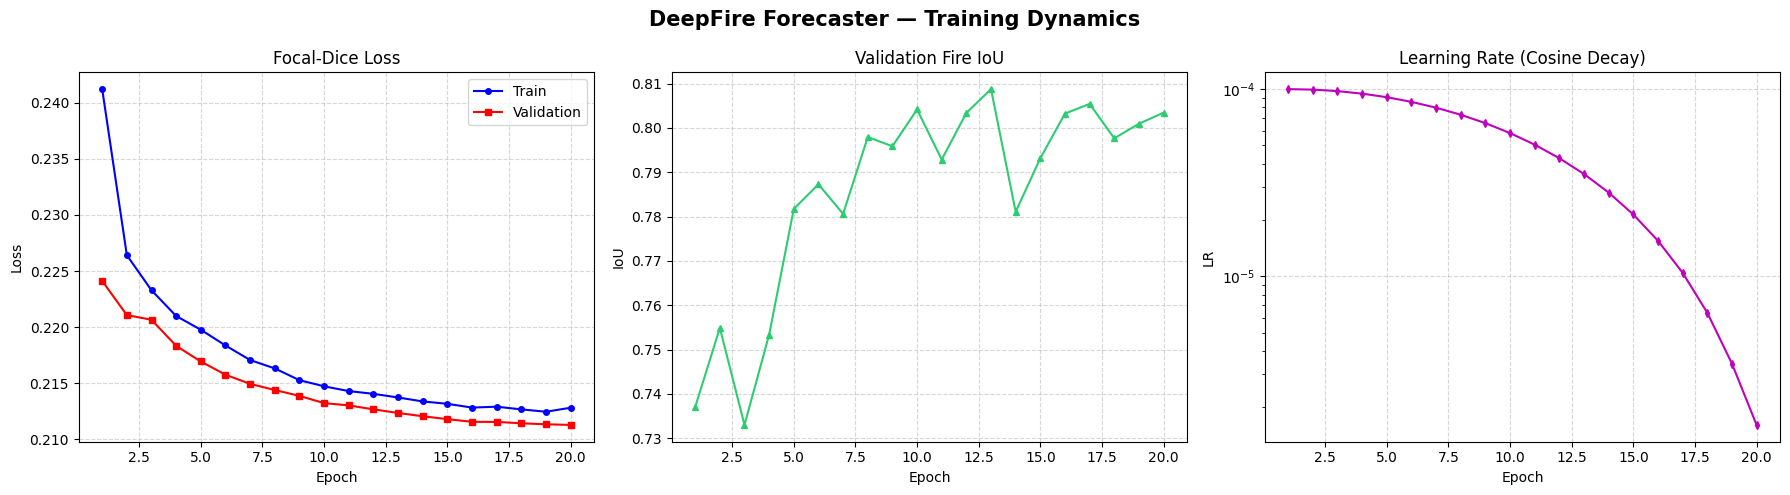

Saved: /kaggle/working/evaluation/plots/learning_curves.png


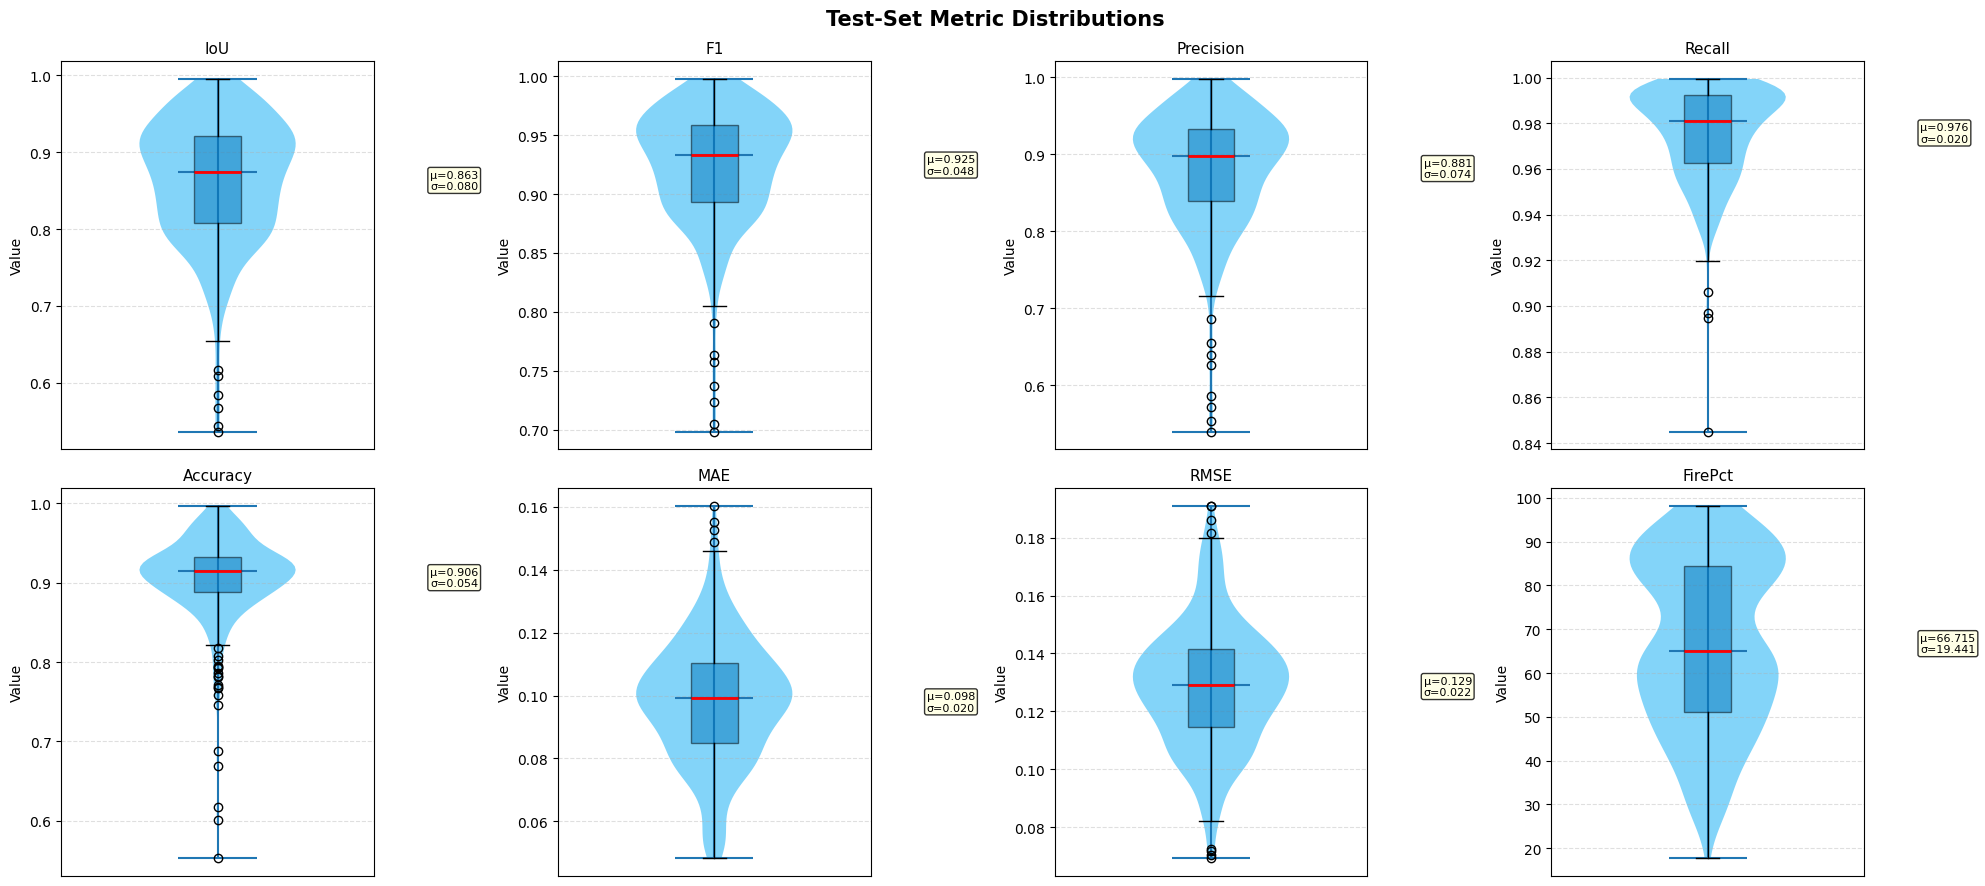

Saved: /kaggle/working/evaluation/plots/metric_distributions.png


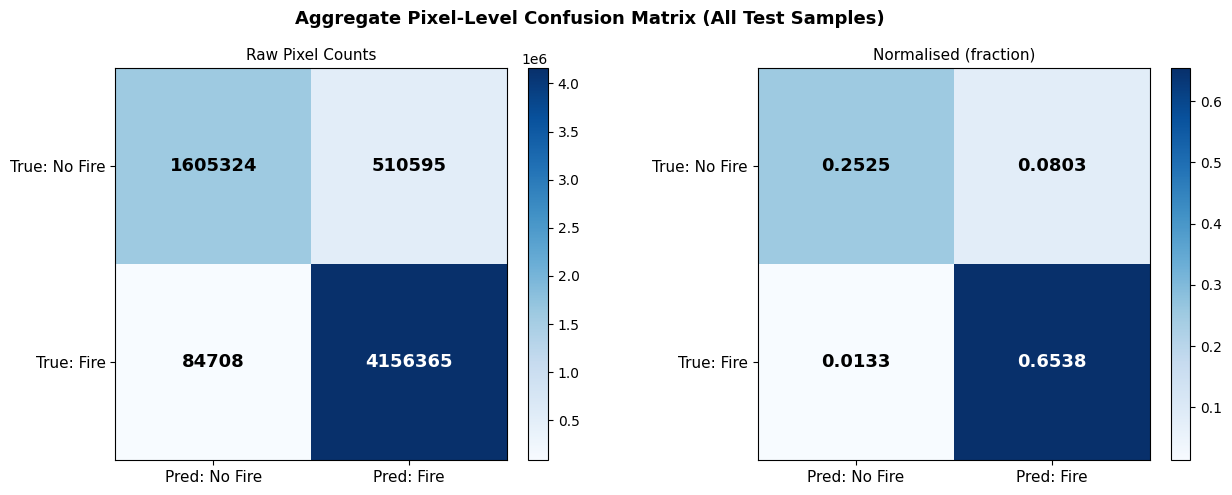

Saved: /kaggle/working/evaluation/plots/confusion_matrix.png


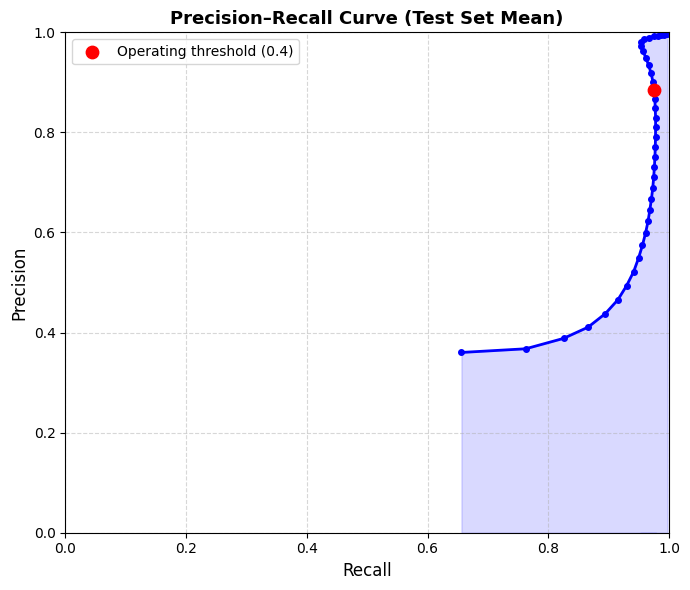

Saved: /kaggle/working/evaluation/plots/precision_recall_curve.png


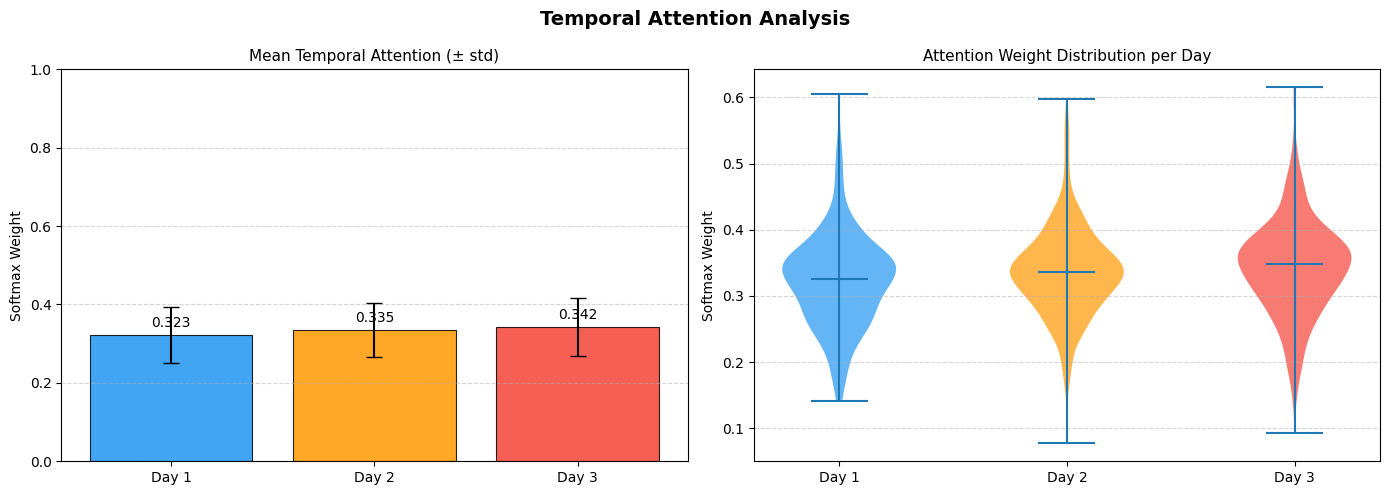

Saved: /kaggle/working/evaluation/plots/temporal_attention.png


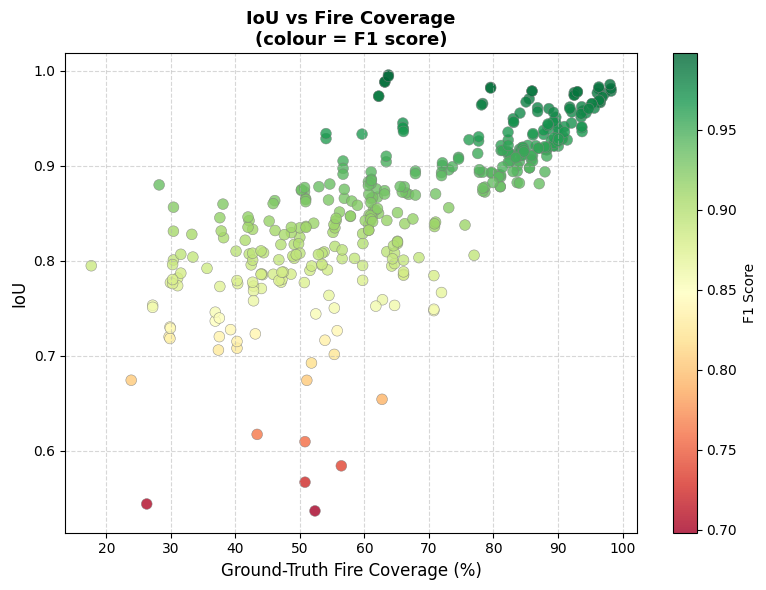

Saved: /kaggle/working/evaluation/plots/iou_vs_fire_coverage.png

═══════════════════════════════════════════════════════════════════════════
  Layer / Module                 Type                           Params Trainable
───────────────────────────────────────────────────────────────────────────
  lulc_embed                     Embedding                          96        96
  spatial_encoder                SpatialEncoder                302,592   302,592
  transformer                    SpatiotemporalTransformer     628,224   628,224
  temporal_pool                  TemporalAttentionPooling        8,321     8,321
  decoder                        UNetDecoder                   382,497   382,497
    spatial_encoder.enc1         ResidualCNNBlock               15,104    15,104
    spatial_encoder.pool1        MaxPool2d                           0         0
    spatial_encoder.enc2         ResidualCNNBlock               57,600    57,600
    spatial_encoder.pool2        MaxPool2d           

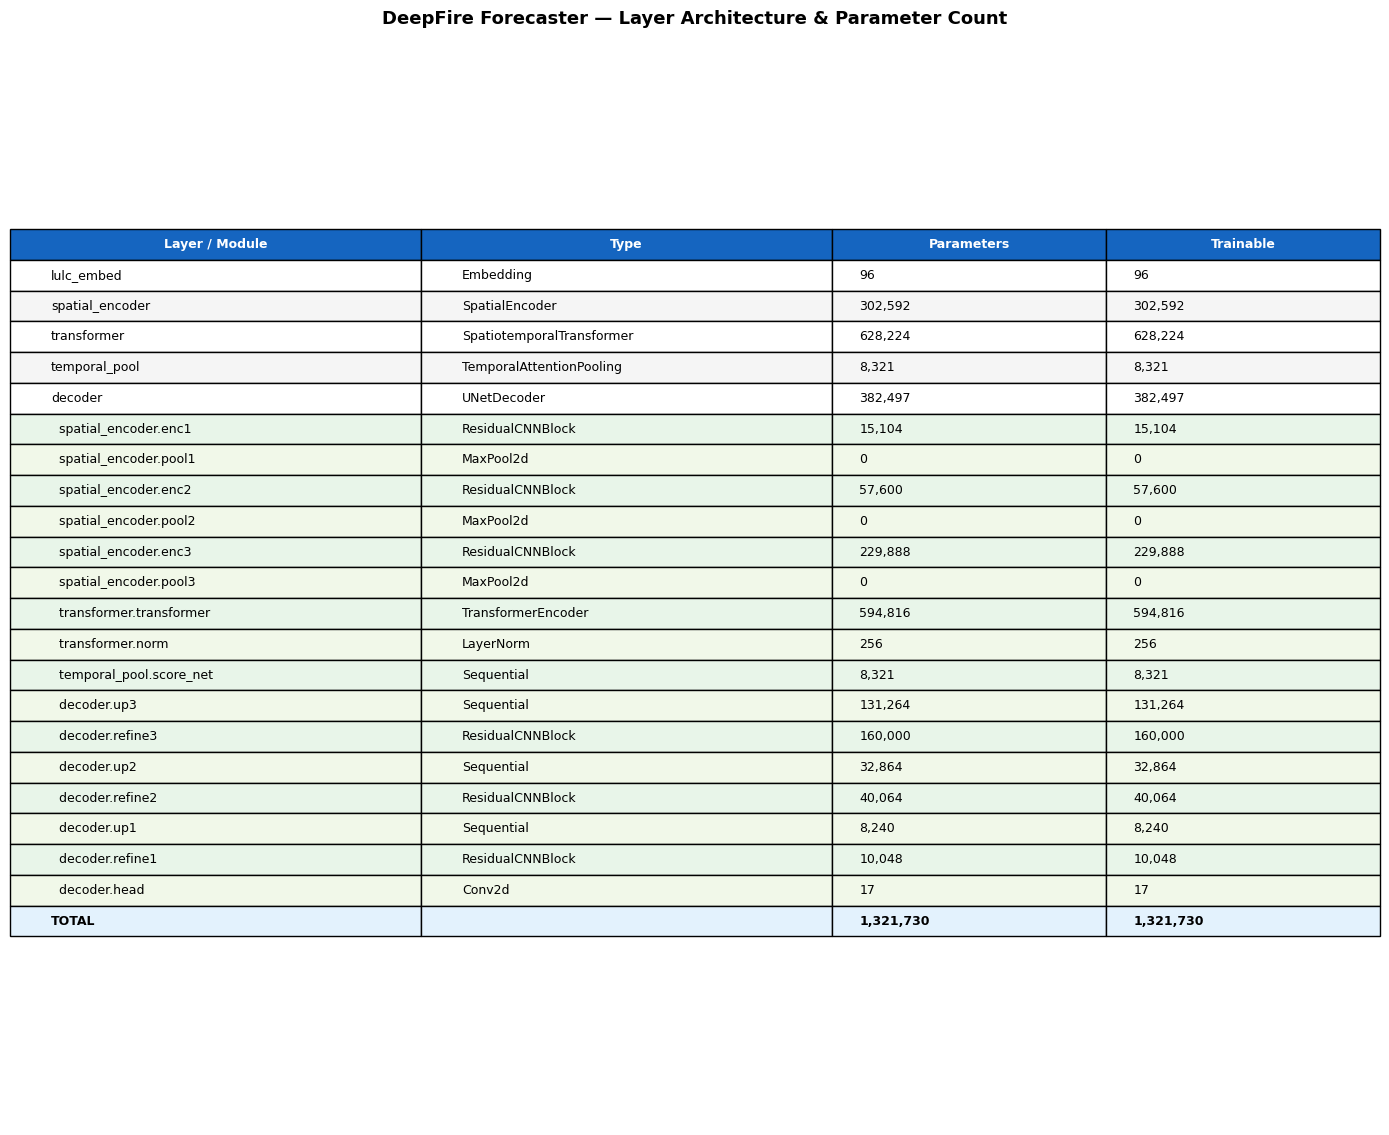

Saved: /kaggle/working/evaluation/plots/architecture_table.png

✅ Block 8 complete. All outputs in: /kaggle/working/evaluation


In [13]:
import os, math
import numpy as np
import torch
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
from collections import OrderedDict
import warnings
warnings.filterwarnings("ignore", message="enable_nested_tensor")

# ═══════════════════════════════════════════════════════════════════════════════
# 8.0  Setup — load best checkpoint, create output directories
# ═══════════════════════════════════════════════════════════════════════════════
checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint["model"])
model.eval()
print(f"Loaded best checkpoint  (epoch {checkpoint['epoch']}, val_loss={checkpoint['val_loss']:.5f})")

EVAL_DIR     = os.path.join(SAVE_DIR, "evaluation")
SAMPLES_DIR  = os.path.join(EVAL_DIR, "test_samples")
PLOTS_DIR    = os.path.join(EVAL_DIR, "plots")
STATS_DIR    = os.path.join(EVAL_DIR, "stats")
for d in [EVAL_DIR, SAMPLES_DIR, PLOTS_DIR, STATS_DIR]:
    os.makedirs(d, exist_ok=True)

THRESHOLD = 0.4   # probability threshold for binary fire/no-fire classification


# ═══════════════════════════════════════════════════════════════════════════════
# 8.1  Helper metrics
# ═══════════════════════════════════════════════════════════════════════════════
def compute_metrics(pred_prob, target, thresh=THRESHOLD):
    """
    pred_prob, target : numpy arrays [H, W] in [0, 1]
    Returns dict of scalar metrics.
    """
    pred_bin = (pred_prob >= thresh).astype(np.float32)
    tgt_bin  = (target    >= thresh).astype(np.float32)

    tp = float((pred_bin * tgt_bin).sum())
    fp = float((pred_bin * (1 - tgt_bin)).sum())
    fn = float(((1 - pred_bin) * tgt_bin).sum())
    tn = float(((1 - pred_bin) * (1 - tgt_bin)).sum())
    n  = pred_prob.size

    eps = 1e-7
    precision  = tp / (tp + fp + eps)
    recall     = tp / (tp + fn + eps)
    f1         = 2 * precision * recall / (precision + recall + eps)
    iou        = tp / (tp + fp + fn + eps)
    accuracy   = (tp + tn) / n
    mae        = float(np.abs(pred_prob - target).mean())
    rmse       = float(np.sqrt(((pred_prob - target) ** 2).mean()))
    fire_pct   = float(tgt_bin.mean() * 100)

    return dict(TP=tp, FP=fp, FN=fn, TN=tn,
                Precision=precision, Recall=recall,
                F1=f1, IoU=iou, Accuracy=accuracy,
                MAE=mae, RMSE=rmse, FirePct=fire_pct)


# ═══════════════════════════════════════════════════════════════════════════════
# 8.2  Per-sample subfolder: 6 images + metrics.txt
# ═══════════════════════════════════════════════════════════════════════════════
all_metrics = []
n_test = len(test_ds)
print(f"\nGenerating per-sample outputs for {n_test} test events …")

with torch.no_grad():
    for idx in range(n_test):
        viirs_b, lulc_b, tgt_b = test_ds[idx]
        pred_t, attn = model(
            viirs_b.unsqueeze(0).to(DEVICE),
            lulc_b.unsqueeze(0).to(DEVICE)
        )

        pred_np = pred_t.cpu().squeeze().numpy()          # [H, W]
        tgt_np  = tgt_b.squeeze().numpy()                 # [H, W]
        viirs_np = viirs_b.numpy()                        # [T, C, H, W]

        metrics = compute_metrics(pred_np, tgt_np)
        metrics["sample_idx"] = idx
        all_metrics.append(metrics)

        # ── per-sample subfolder ──────────────────────────────────────────────
        sample_dir = os.path.join(SAMPLES_DIR, f"sample_{idx:04d}")
        os.makedirs(sample_dir, exist_ok=True)

        cmap_thermal = plt.cm.viridis
        cmap_fire    = plt.cm.inferno

        def _save(arr, cmap, fname, title, vmin=0, vmax=1):
            fig, ax = plt.subplots(figsize=(5, 5))
            im = ax.imshow(arr, cmap=cmap, vmin=vmin, vmax=vmax)
            ax.set_title(title, fontsize=11, pad=6)
            ax.axis("off")
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            fig.tight_layout()
            fig.savefig(os.path.join(sample_dir, fname), dpi=150, bbox_inches="tight")
            plt.close(fig)

        # Day 1, 2, 3 — first thermal band
        for day in range(3):
            _save(viirs_np[day, 0], cmap_thermal,
                  f"day_{day+1}_thermal.png",
                  f"Input Day {day+1} — VIIRS Thermal (Band 1, normalised)")

        # Model prediction
        _save(pred_np, cmap_fire,
              "day4_prediction.png",
              f"Day 4 Predicted Fire Probability\n(IoU={metrics['IoU']:.3f}  F1={metrics['F1']:.3f})")

        # Ground truth
        _save(tgt_np, cmap_fire,
              "day4_ground_truth.png",
              "Day 4 Ground Truth Fire Map")

        # Pixel-accuracy map: blue = TP, red = FP+FN, white = TN
        pred_bin = (pred_np >= THRESHOLD).astype(int)
        tgt_bin  = (tgt_np  >= THRESHOLD).astype(int)
        # Encode: 0=TN, 1=TP, 2=FP, 3=FN
        pix_map = np.zeros_like(pred_bin, dtype=int)
        pix_map[(pred_bin == 1) & (tgt_bin == 1)] = 1   # TP
        pix_map[(pred_bin == 1) & (tgt_bin == 0)] = 2   # FP
        pix_map[(pred_bin == 0) & (tgt_bin == 1)] = 3   # FN

        cmap_pix = ListedColormap(["#f0f0f0", "#2196F3", "#F44336", "#FF9800"])
        fig, ax  = plt.subplots(figsize=(5, 5))
        im = ax.imshow(pix_map, cmap=cmap_pix, vmin=0, vmax=3, interpolation="nearest")
        ax.set_title(f"Pixel Classification Map\n"
                     f"Prec={metrics['Precision']:.3f}  Rec={metrics['Recall']:.3f}  F1={metrics['F1']:.3f}",
                     fontsize=10, pad=6)
        ax.axis("off")
        patches = [
            mpatches.Patch(color="#f0f0f0", label="TN — correct background"),
            mpatches.Patch(color="#2196F3", label="TP — correct fire"),
            mpatches.Patch(color="#F44336", label="FP — false alarm"),
            mpatches.Patch(color="#FF9800", label="FN — missed fire"),
        ]
        ax.legend(handles=patches, loc="lower left", fontsize=7,
                  framealpha=0.85, borderpad=0.5)
        fig.tight_layout()
        fig.savefig(os.path.join(sample_dir, "pixel_accuracy_map.png"),
                    dpi=150, bbox_inches="tight")
        plt.close(fig)

        # metrics.txt
        with open(os.path.join(sample_dir, "metrics.txt"), "w") as f:
            f.write(f"Sample index : {idx}\n")
            f.write(f"Threshold    : {THRESHOLD}\n\n")
            for k, v in metrics.items():
                if k != "sample_idx":
                    f.write(f"  {k:<12}: {v:.5f}\n")

        if (idx + 1) % 10 == 0 or idx == n_test - 1:
            print(f"  [{idx+1}/{n_test}] done")

print("✅ Per-sample subfolders complete.")


# ═══════════════════════════════════════════════════════════════════════════════
# 8.3  Aggregate statistics table
# ═══════════════════════════════════════════════════════════════════════════════
keys = ["IoU", "F1", "Precision", "Recall", "Accuracy", "MAE", "RMSE", "FirePct"]
agg  = {k: np.array([m[k] for m in all_metrics]) for k in keys}

print("\n" + "═"*58)
print(f"  {'Metric':<14} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8}")
print("─"*58)
for k in keys:
    print(f"  {k:<14} {agg[k].mean():>8.4f} {agg[k].std():>8.4f} "
          f"{agg[k].min():>8.4f} {agg[k].max():>8.4f}")
print("═"*58)

# Save as CSV
import csv
csv_path = os.path.join(STATS_DIR, "test_metrics.csv")
with open(csv_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["sample_idx"] + keys)
    writer.writeheader()
    for m in all_metrics:
        writer.writerow({k: round(m[k], 6) for k in ["sample_idx"] + keys})
print(f"\nMetrics CSV saved → {csv_path}")


# ═══════════════════════════════════════════════════════════════════════════════
# 8.4  Learning curves  (3-panel)
# ═══════════════════════════════════════════════════════════════════════════════
history = checkpoint["history"]
epochs_x = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("DeepFire Forecaster — Training Dynamics", fontsize=15, fontweight="bold")

axes[0].plot(epochs_x, history["train_loss"], "b-o", ms=4, label="Train")
axes[0].plot(epochs_x, history["val_loss"],   "r-s", ms=4, label="Validation")
axes[0].set_title("Focal-Dice Loss"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(True, linestyle="--", alpha=0.5)

axes[1].plot(epochs_x, history["val_iou"], "g-^", ms=4, color="#2ecc71")
axes[1].set_title("Validation Fire IoU"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("IoU")
axes[1].grid(True, linestyle="--", alpha=0.5)

axes[2].plot(epochs_x, history["lr"], "m-d", ms=4)
axes[2].set_title("Learning Rate (Cosine Decay)")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("LR")
axes[2].set_yscale("log"); axes[2].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
p = os.path.join(PLOTS_DIR, "learning_curves.png")
plt.savefig(p, dpi=200, bbox_inches="tight"); plt.show(); plt.close()
print(f"Saved: {p}")


# ═══════════════════════════════════════════════════════════════════════════════
# 8.5  Test-set metric distributions  (box + violin)
# ═══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle("Test-Set Metric Distributions", fontsize=15, fontweight="bold")

for ax, k in zip(axes.flat, keys):
    data = agg[k]
    parts = ax.violinplot(data, showmedians=True, showextrema=True)
    for pc in parts["bodies"]:
        pc.set_facecolor("#4FC3F7"); pc.set_alpha(0.7)
    ax.boxplot(data, widths=0.15, patch_artist=True,
               boxprops=dict(facecolor="#0277BD", alpha=0.5),
               medianprops=dict(color="red", linewidth=2))
    ax.set_title(k, fontsize=11)
    ax.set_xticks([])
    ax.set_ylabel("Value")
    ax.text(1.18, data.mean(), f"μ={data.mean():.3f}\nσ={data.std():.3f}",
            transform=ax.get_yaxis_transform(), fontsize=8, va="center",
            bbox=dict(boxstyle="round,pad=0.2", facecolor="lightyellow", alpha=0.8))
    ax.grid(True, linestyle="--", alpha=0.4, axis="y")

plt.tight_layout()
p = os.path.join(PLOTS_DIR, "metric_distributions.png")
plt.savefig(p, dpi=200, bbox_inches="tight"); plt.show(); plt.close()
print(f"Saved: {p}")


# ═══════════════════════════════════════════════════════════════════════════════
# 8.6  Confusion matrix (aggregate over all test pixels)
# ═══════════════════════════════════════════════════════════════════════════════
total_tp = sum(m["TP"] for m in all_metrics)
total_fp = sum(m["FP"] for m in all_metrics)
total_fn = sum(m["FN"] for m in all_metrics)
total_tn = sum(m["TN"] for m in all_metrics)
cm = np.array([[total_tn, total_fp], [total_fn, total_tp]])
cm_norm = cm / cm.sum()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Aggregate Pixel-Level Confusion Matrix (All Test Samples)",
             fontsize=13, fontweight="bold")

for ax, mat, title, fmt in zip(
    axes,
    [cm, cm_norm],
    ["Raw Pixel Counts", "Normalised (fraction)"],
    [".0f", ".4f"]
):
    im = ax.imshow(mat, cmap="Blues")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred: No Fire", "Pred: Fire"], fontsize=11)
    ax.set_yticklabels(["True: No Fire", "True: Fire"], fontsize=11)
    ax.set_title(title, fontsize=11)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, format(mat[i, j], fmt),
                    ha="center", va="center",
                    color="white" if mat[i, j] > mat.max() * 0.6 else "black",
                    fontsize=13, fontweight="bold")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
p = os.path.join(PLOTS_DIR, "confusion_matrix.png")
plt.savefig(p, dpi=200, bbox_inches="tight"); plt.show(); plt.close()
print(f"Saved: {p}")


# ═══════════════════════════════════════════════════════════════════════════════
# 8.7  Precision-Recall curve (averaged over test samples)
# ═══════════════════════════════════════════════════════════════════════════════
thresholds = np.linspace(0.05, 0.95, 40)
mean_prec, mean_rec = [], []

with torch.no_grad():
    # Collect all predictions and targets once
    all_preds, all_tgts = [], []
    for idx in range(n_test):
        viirs_b, lulc_b, tgt_b = test_ds[idx]
        pred_t, _ = model(viirs_b.unsqueeze(0).to(DEVICE),
                          lulc_b.unsqueeze(0).to(DEVICE))
        all_preds.append(pred_t.cpu().squeeze().numpy())
        all_tgts.append(tgt_b.squeeze().numpy())

for th in thresholds:
    precs, recs = [], []
    for pred_np, tgt_np in zip(all_preds, all_tgts):
        m = compute_metrics(pred_np, tgt_np, thresh=th)
        precs.append(m["Precision"]); recs.append(m["Recall"])
    mean_prec.append(np.mean(precs))
    mean_rec.append(np.mean(recs))

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(mean_rec, mean_prec, "b-o", ms=4, linewidth=2)
ax.fill_between(mean_rec, mean_prec, alpha=0.15, color="blue")
ax.set_xlabel("Recall",    fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.set_title("Precision–Recall Curve (Test Set Mean)", fontsize=13, fontweight="bold")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.grid(True, linestyle="--", alpha=0.5)
# Mark operating threshold
idx_op = np.argmin(np.abs(thresholds - THRESHOLD))
ax.scatter(mean_rec[idx_op], mean_prec[idx_op], color="red", zorder=5, s=80,
           label=f"Operating threshold ({THRESHOLD})")
ax.legend(fontsize=10)
plt.tight_layout()
p = os.path.join(PLOTS_DIR, "precision_recall_curve.png")
plt.savefig(p, dpi=200, bbox_inches="tight"); plt.show(); plt.close()
print(f"Saved: {p}")


# ═══════════════════════════════════════════════════════════════════════════════
# 8.8  Temporal attention weights (all test samples)
# ═══════════════════════════════════════════════════════════════════════════════
all_attn = []
with torch.no_grad():
    for idx in range(n_test):
        viirs_b, lulc_b, _ = test_ds[idx]
        _, attn = model(viirs_b.unsqueeze(0).to(DEVICE),
                        lulc_b.unsqueeze(0).to(DEVICE))
        all_attn.append(attn.cpu().numpy().squeeze())

attn_arr = np.stack(all_attn, axis=0)   # [N, T]
attn_mean = attn_arr.mean(axis=0)
attn_std  = attn_arr.std(axis=0)
days = [f"Day {i+1}" for i in range(SEQ_LEN)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Temporal Attention Analysis", fontsize=14, fontweight="bold")

# Mean ± std bar chart
colors = ["#2196F3", "#FF9800", "#F44336"][:SEQ_LEN]
bars = axes[0].bar(days, attn_mean, color=colors, yerr=attn_std,
                   capsize=6, alpha=0.85, edgecolor="black", linewidth=0.8)
axes[0].set_title("Mean Temporal Attention (± std)", fontsize=11)
axes[0].set_ylabel("Softmax Weight"); axes[0].set_ylim(0, 1)
axes[0].grid(axis="y", linestyle="--", alpha=0.5)
for bar, v in zip(bars, attn_mean):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f"{v:.3f}", ha="center", fontsize=10)

# Distribution violin per day
parts = axes[1].violinplot([attn_arr[:, t] for t in range(SEQ_LEN)],
                            showmedians=True)
for pc, c in zip(parts["bodies"], colors):
    pc.set_facecolor(c); pc.set_alpha(0.7)
axes[1].set_xticks(range(1, SEQ_LEN + 1)); axes[1].set_xticklabels(days)
axes[1].set_title("Attention Weight Distribution per Day", fontsize=11)
axes[1].set_ylabel("Softmax Weight")
axes[1].grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
p = os.path.join(PLOTS_DIR, "temporal_attention.png")
plt.savefig(p, dpi=200, bbox_inches="tight"); plt.show(); plt.close()
print(f"Saved: {p}")


# ═══════════════════════════════════════════════════════════════════════════════
# 8.9  IoU vs Fire Coverage scatter (does model struggle on small fires?)
# ═══════════════════════════════════════════════════════════════════════════════
fire_pcts = agg["FirePct"]
ious      = agg["IoU"]

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(fire_pcts, ious, c=agg["F1"], cmap="RdYlGn",
                s=60, alpha=0.8, edgecolors="grey", linewidths=0.4)
fig.colorbar(sc, ax=ax, label="F1 Score")
ax.set_xlabel("Ground-Truth Fire Coverage (%)", fontsize=12)
ax.set_ylabel("IoU", fontsize=12)
ax.set_title("IoU vs Fire Coverage\n(colour = F1 score)", fontsize=13, fontweight="bold")
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
p = os.path.join(PLOTS_DIR, "iou_vs_fire_coverage.png")
plt.savefig(p, dpi=200, bbox_inches="tight"); plt.show(); plt.close()
print(f"Saved: {p}")


# ═══════════════════════════════════════════════════════════════════════════════
# 8.10  Model Architecture Table
# ═══════════════════════════════════════════════════════════════════════════════
def count_params(module):
    return sum(p.numel() for p in module.parameters())

def count_trainable(module):
    return sum(p.numel() for p in module.parameters() if p.requires_grad)

rows = []

# Top-level submodules
for name, submod in model.named_children():
    rows.append((name, type(submod).__name__, count_params(submod), count_trainable(submod)))

# One level deeper for the encoder and decoder
for top_name, top_mod in model.named_children():
    children = list(top_mod.named_children())
    if children:
        for child_name, child_mod in children:
            rows.append((
                f"  {top_name}.{child_name}",
                type(child_mod).__name__,
                count_params(child_mod),
                count_trainable(child_mod)
            ))

total_p = count_params(model)
train_p = count_trainable(model)

print("\n" + "═"*75)
print(f"  {'Layer / Module':<30} {'Type':<28} {'Params':>8} {'Trainable':>9}")
print("─"*75)
for name, ttype, p, tp in rows:
    print(f"  {name:<30} {ttype:<28} {p:>8,} {tp:>9,}")
print("─"*75)
print(f"  {'TOTAL':<30} {'':<28} {total_p:>8,} {train_p:>9,}")
print("═"*75)

# Save as text file
arch_path = os.path.join(STATS_DIR, "model_architecture.txt")
with open(arch_path, "w") as f:
    f.write(f"DeepFire Forecaster — Architecture Summary\n")
    f.write(f"Generated: {__import__('datetime').datetime.now().strftime('%Y-%m-%d %H:%M')}\n\n")
    f.write(f"Configuration:\n")
    f.write(f"  SPATIAL_SIZE    : {SPATIAL_SIZE}\n")
    f.write(f"  SEQ_LEN         : {SEQ_LEN}\n")
    f.write(f"  VIIRS channels  : {C_VIIRS} (day{'+ night' if USE_NIGHT else ' only'})\n")
    f.write(f"  EMBED_DIM       : {EMBED_DIM}\n")
    f.write(f"  NUM_HEADS       : {NUM_HEADS}\n")
    f.write(f"  NUM_LAYERS      : {NUM_LAYERS}\n")
    f.write(f"  LULC_EMBED_DIM  : {LULC_EMBED_DIM}\n\n")
    f.write("═"*75 + "\n")
    f.write(f"  {'Layer / Module':<30} {'Type':<28} {'Params':>8} {'Trainable':>9}\n")
    f.write("─"*75 + "\n")
    for name, ttype, p, tp in rows:
        f.write(f"  {name:<30} {ttype:<28} {p:>8,} {tp:>9,}\n")
    f.write("─"*75 + "\n")
    f.write(f"  {'TOTAL':<30} {'':<28} {total_p:>8,} {train_p:>9,}\n")
    f.write("═"*75 + "\n\n")
    f.write("Full model repr:\n\n")
    f.write(str(model))

print(f"\nArchitecture summary saved → {arch_path}")

# ── also render as a matplotlib figure for the paper ─────────────────────────
fig, ax = plt.subplots(figsize=(14, max(5, len(rows) * 0.45 + 2)))
ax.axis("off")
col_labels = ["Layer / Module", "Type", "Parameters", "Trainable"]
table_data = [[n, t, f"{p:,}", f"{tp:,}"] for n, t, p, tp in rows]
table_data.append(["TOTAL", "", f"{total_p:,}", f"{train_p:,}"])

tbl = ax.table(
    cellText=table_data,
    colLabels=col_labels,
    cellLoc="left",
    loc="center",
    colWidths=[0.30, 0.30, 0.20, 0.20],
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.5)

# Header styling
for j in range(4):
    tbl[(0, j)].set_facecolor("#1565C0")
    tbl[(0, j)].set_text_props(color="white", fontweight="bold")

# Total row styling
last = len(table_data)
for j in range(4):
    tbl[(last, j)].set_facecolor("#E3F2FD")
    tbl[(last, j)].set_text_props(fontweight="bold")

# Alternating row colours
for i in range(1, last):
    c = "#F5F5F5" if i % 2 == 0 else "white"
    # Indent sub-module rows
    if table_data[i-1][0].startswith("  "):
        c = "#E8F5E9" if i % 2 == 0 else "#F1F8E9"
    for j in range(4):
        tbl[(i, j)].set_facecolor(c)

ax.set_title("DeepFire Forecaster — Layer Architecture & Parameter Count",
             fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
p = os.path.join(PLOTS_DIR, "architecture_table.png")
plt.savefig(p, dpi=200, bbox_inches="tight"); plt.show(); plt.close()
print(f"Saved: {p}")

print("\n✅ Block 8 complete. All outputs in:", EVAL_DIR)


## 9. Download Outputs

Test sample subfolders found : 388
Plotting random sample       : sample_0183


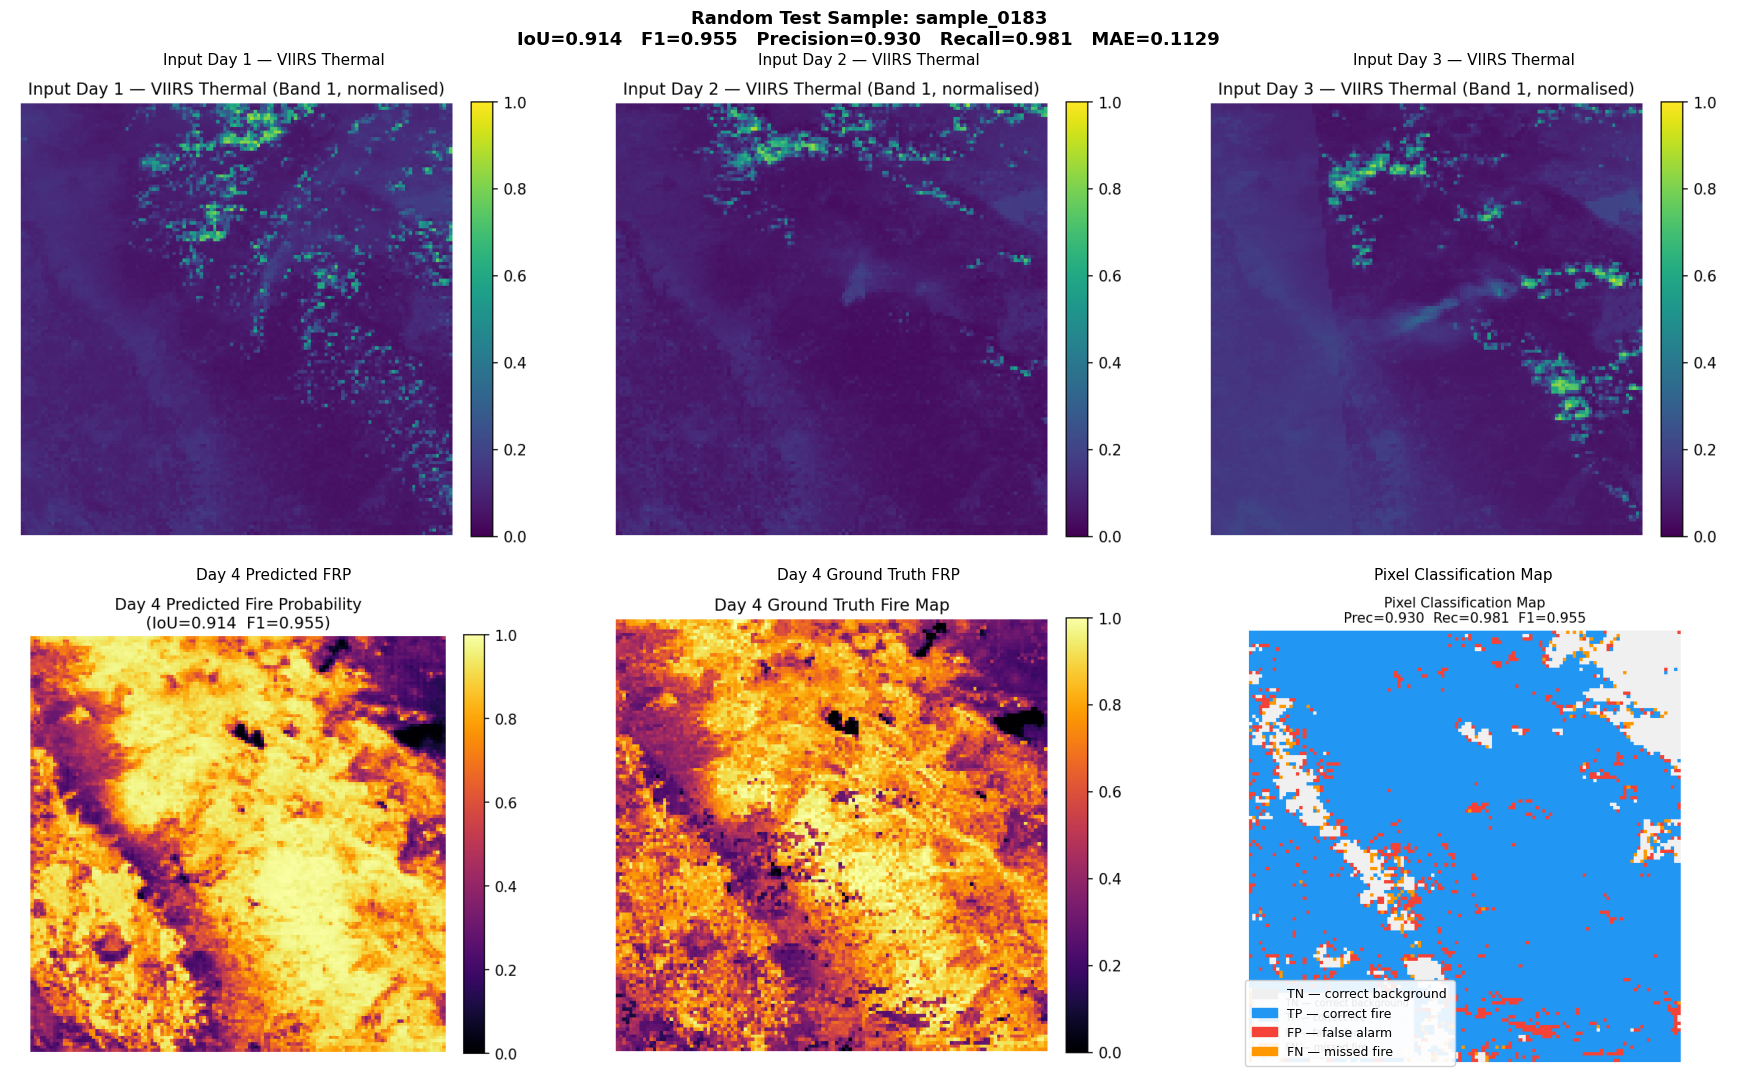

Random sample plot saved.

Building master zip: /kaggle/working/deepfire_all_outputs.zip
  Adding model checkpoint ...
  Adding plots ...
  Adding stats ...
  Adding test sample subfolders ...

  📦  ALL OUTPUTS READY FOR DOWNLOAD
  Zip file   : /kaggle/working/deepfire_all_outputs.zip
  Size       : 165.0 MB

  Contents:
    deepfire_best.pt          — trained model weights
    plots/    (  8 files)    — learning curves, confusion matrix,
                                 PR curve, attention, IoU scatter,
                                 architecture table, random sample
    stats/    (  2 files)    — test_metrics.csv, model_architecture.txt
    test_samples/ (388 folders) — 2328 images total
      each folder: day_1/2/3_thermal, day4_prediction,
                   day4_ground_truth, pixel_accuracy_map, metrics.txt

  ➡  Go to Kaggle sidebar → Output tab to download the zip.


In [19]:
# ═══════════════════════════════════════════════════════════════════════════════
# 9. PACKAGE ALL OUTPUTS FOR DOWNLOAD
# Collects every output (model, plots, stats, test samples) into a single
# zip file at /kaggle/working/deepfire_all_outputs.zip
# ═══════════════════════════════════════════════════════════════════════════════
import os, glob, zipfile, random, shutil
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

EVAL_DIR     = os.path.join(SAVE_DIR, "evaluation")
PLOTS_DIR    = os.path.join(EVAL_DIR, "plots")
STATS_DIR    = os.path.join(EVAL_DIR, "stats")
SAMPLES_DIR  = os.path.join(EVAL_DIR, "test_samples")
ZIP_PATH     = os.path.join(SAVE_DIR, "deepfire_all_outputs.zip")

# ── 1. Plot one random test sample inline ─────────────────────────────────────
sample_dirs = sorted(glob.glob(os.path.join(SAMPLES_DIR, "sample_*")))
print(f"Test sample subfolders found : {len(sample_dirs)}")

if sample_dirs:
    sd = random.choice(sample_dirs)
    sample_name = os.path.basename(sd)
    print(f"Plotting random sample       : {sample_name}")

    day1  = np.array(Image.open(os.path.join(sd, "day_1_thermal.png")))
    day2  = np.array(Image.open(os.path.join(sd, "day_2_thermal.png")))
    day3  = np.array(Image.open(os.path.join(sd, "day_3_thermal.png")))
    pred  = np.array(Image.open(os.path.join(sd, "day4_prediction.png")))
    truth = np.array(Image.open(os.path.join(sd, "day4_ground_truth.png")))
    pmap  = np.array(Image.open(os.path.join(sd, "pixel_accuracy_map.png")))

    metrics_dict = {}
    metrics_path = os.path.join(sd, "metrics.txt")
    if os.path.exists(metrics_path):
        for line in open(metrics_path).read().split("\n"):
            if ":" in line and "Sample" not in line and "Threshold" not in line:
                k, v = line.split(":", 1)
                try:
                    metrics_dict[k.strip()] = float(v.strip())
                except:
                    pass

    fig, axes = plt.subplots(2, 3, figsize=(18, 11))
    fig.suptitle(
        f"Random Test Sample: {sample_name}\n"
        f"IoU={metrics_dict.get('IoU',0):.3f}   F1={metrics_dict.get('F1',0):.3f}   "
        f"Precision={metrics_dict.get('Precision',0):.3f}   "
        f"Recall={metrics_dict.get('Recall',0):.3f}   "
        f"MAE={metrics_dict.get('MAE',0):.4f}",
        fontsize=13, fontweight="bold"
    )

    for ax, (img, title) in zip(axes.flat, [
        (day1,  "Input Day 1 — VIIRS Thermal"),
        (day2,  "Input Day 2 — VIIRS Thermal"),
        (day3,  "Input Day 3 — VIIRS Thermal"),
        (pred,  "Day 4 Predicted FRP"),
        (truth, "Day 4 Ground Truth FRP"),
        (pmap,  "Pixel Classification Map"),
    ]):
        ax.imshow(img)
        ax.set_title(title, fontsize=11, pad=6)
        ax.axis("off")

    patches = [
        mpatches.Patch(color="#f0f0f0", label="TN — correct background"),
        mpatches.Patch(color="#2196F3", label="TP — correct fire"),
        mpatches.Patch(color="#F44336", label="FP — false alarm"),
        mpatches.Patch(color="#FF9800", label="FN — missed fire"),
    ]
    axes[1, 2].legend(handles=patches, loc="lower left", fontsize=9,
                      framealpha=0.9, borderpad=0.6)
    plt.tight_layout()

    # Save to plots dir so it gets included in the zip
    random_sample_plot = os.path.join(PLOTS_DIR, "random_test_sample.png")
    plt.savefig(random_sample_plot, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"Random sample plot saved.\n")

# ── 2. Build the master zip ───────────────────────────────────────────────────
print(f"Building master zip: {ZIP_PATH}")
print("  Adding model checkpoint ...")
print("  Adding plots ...")
print("  Adding stats ...")
print("  Adding test sample subfolders ...")

with zipfile.ZipFile(ZIP_PATH, "w", zipfile.ZIP_DEFLATED) as zf:

    # Model checkpoint
    if os.path.exists(MODEL_PATH):
        zf.write(MODEL_PATH, "deepfire_best.pt")

    # All plots
    for f in sorted(glob.glob(os.path.join(PLOTS_DIR, "*.png"))):
        zf.write(f, os.path.join("plots", os.path.basename(f)))

    # Stats files
    for f in sorted(glob.glob(os.path.join(STATS_DIR, "*"))):
        zf.write(f, os.path.join("stats", os.path.basename(f)))

    # Every test sample subfolder (6 images + metrics.txt each)
    for sd in sorted(glob.glob(os.path.join(SAMPLES_DIR, "sample_*"))):
        folder_name = os.path.basename(sd)
        for fpath in sorted(glob.glob(os.path.join(sd, "*"))):
            arcname = os.path.join("test_samples", folder_name, os.path.basename(fpath))
            zf.write(fpath, arcname)

zip_mb = os.path.getsize(ZIP_PATH) / 1e6

# ── 3. Print summary ──────────────────────────────────────────────────────────
print()
print("=" * 62)
print("  📦  ALL OUTPUTS READY FOR DOWNLOAD")
print("=" * 62)
print(f"  Zip file   : {ZIP_PATH}")
print(f"  Size       : {zip_mb:.1f} MB")
print()

# List zip contents summary
with zipfile.ZipFile(ZIP_PATH) as zf:
    names = zf.namelist()
n_plots   = sum(1 for n in names if n.startswith("plots/"))
n_stats   = sum(1 for n in names if n.startswith("stats/"))
n_samples = sum(1 for n in names if "test_samples/sample_" in n and n.endswith(".png"))
n_folders = len(set(n.split("/")[1] for n in names if n.startswith("test_samples/sample_")))

print(f"  Contents:")
print(f"    deepfire_best.pt          — trained model weights")
print(f"    plots/    ({n_plots:3d} files)    — learning curves, confusion matrix,")
print(f"                                 PR curve, attention, IoU scatter,")
print(f"                                 architecture table, random sample")
print(f"    stats/    ({n_stats:3d} files)    — test_metrics.csv, model_architecture.txt")
print(f"    test_samples/ ({n_folders} folders) — {n_samples} images total")
print(f"      each folder: day_1/2/3_thermal, day4_prediction,")
print(f"                   day4_ground_truth, pixel_accuracy_map, metrics.txt")
print("=" * 62)
print()
print("  ➡  Go to Kaggle sidebar → Output tab to download the zip.")


In [20]:
import os
path = "/kaggle/working/deepfire_all_outputs.zip"
if os.path.exists(path):
    print(f"EXISTS: {os.path.getsize(path)/1e6:.1f} MB")
else:
    print("NOT FOUND")

EXISTS: 165.0 MB


In [22]:
import os, zipfile, glob, math

ZIP_PATH   = "/kaggle/working/deepfire_all_outputs.zip"
CHUNK_SIZE = 50 * 1024 * 1024   # 50 MB chunks

with open(ZIP_PATH, "rb") as f:
    data = f.read()

n_chunks = math.ceil(len(data) / CHUNK_SIZE)
for i in range(n_chunks):
    chunk_path = f"/kaggle/working/deepfire_outputs_part{i+1}of{n_chunks}.zip"
    chunk = data[i*CHUNK_SIZE : (i+1)*CHUNK_SIZE]
    # Write each chunk as its own small zip containing just the raw bytes
    with open(chunk_path, "wb") as f:
        f.write(chunk)
    print(f"Part {i+1}/{n_chunks}: {chunk_path}  ({len(chunk)/1e6:.1f} MB)")

print("\nDownload all parts then rejoin with:")
print("  cat deepfire_outputs_part*.zip > deepfire_all_outputs.zip")

Part 1/4: /kaggle/working/deepfire_outputs_part1of4.zip  (52.4 MB)
Part 2/4: /kaggle/working/deepfire_outputs_part2of4.zip  (52.4 MB)
Part 3/4: /kaggle/working/deepfire_outputs_part3of4.zip  (52.4 MB)
Part 4/4: /kaggle/working/deepfire_outputs_part4of4.zip  (7.7 MB)

Download all parts then rejoin with:
  cat deepfire_outputs_part*.zip > deepfire_all_outputs.zip
